In [7]:
#@title 00R. Safely recover Google Drive after Colab reconnect

from pathlib import Path
from google.colab import drive
import shutil

MOUNT_POINT = Path("/content/drive")
MY_DRIVE = MOUNT_POINT / "MyDrive"

# Case 1: Drive is already usable.
if MY_DRIVE.is_dir():
    print("Google Drive is already mounted and usable.")

# Case 2: A stale /content/drive directory remains after reconnect.
else:
    print("Google Drive is not currently usable.")
    print("Clearing stale mount-point state...")

    try:
        drive.flush_and_unmount()
    except Exception:
        pass

    if MOUNT_POINT.exists():
        shutil.rmtree(MOUNT_POINT)

    drive.mount(
        str(MOUNT_POINT),
        force_remount=True,
    )

assert MY_DRIVE.is_dir(), (
    "Google Drive recovery failed: "
    "/content/drive/MyDrive is unavailable."
)

print("\nGoogle Drive ready:")
print(MY_DRIVE)

Google Drive is already mounted and usable.

Google Drive ready:
/content/drive/MyDrive


In [6]:
#@title 00. Load sealed results and freeze fine-structure protocol

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import json
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

KILL_TEST_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Locality_Kill_Test_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)

FINE_STRUCTURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Sealed input artifacts
# ------------------------------------------------------------

IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_IMAGE_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

BASELINE_DECISION_PATH = (
    BASELINE_ROOT
    / "Frozen_Representation_Baseline_v0.1_Decision.json"
)

KILL_TEST_DECISION_PATH = (
    KILL_TEST_ROOT
    / "Locality_Kill_Test_v0.1_Decision.json"
)

ADAPTIVE_KILL_TEST_PATH = (
    KILL_TEST_ROOT
    / "Kill_Test_PairedDifference_Condition_Summary.csv"
)

FIXED_KILL_TEST_PATH = (
    KILL_TEST_ROOT
    / "Kill_Test_FixedCleanProbe_Condition_Summary.csv"
)

BASELINE_PAIR_PREDICTIONS_PATH = (
    BASELINE_ROOT
    / "Validation_Ordinal_PairedDifference_Predictions.csv"
)

required_paths = [
    IMAGE_INDEX_PATH,
    CLEAN_IMAGE_EMBEDDING_PATH,
    BASELINE_DECISION_PATH,
    KILL_TEST_DECISION_PATH,
    ADAPTIVE_KILL_TEST_PATH,
    FIXED_KILL_TEST_PATH,
    BASELINE_PAIR_PREDICTIONS_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing sealed input artifacts:\n"
        + "\n".join(map(str, missing_paths))
    )


# ------------------------------------------------------------
# 3. Load sealed results
# ------------------------------------------------------------

image_meta = pd.read_csv(
    IMAGE_INDEX_PATH
)

clean_image_embeddings = np.load(
    CLEAN_IMAGE_EMBEDDING_PATH
)

adaptive_kill_results = pd.read_csv(
    ADAPTIVE_KILL_TEST_PATH
)

fixed_kill_results = pd.read_csv(
    FIXED_KILL_TEST_PATH
)

baseline_pair_predictions = pd.read_csv(
    BASELINE_PAIR_PREDICTIONS_PATH
)

with open(
    BASELINE_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    baseline_decision = json.load(file)

with open(
    KILL_TEST_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    kill_test_decision = json.load(file)


# ------------------------------------------------------------
# 4. Verify sealed inputs
# ------------------------------------------------------------

assert (
    baseline_decision["decision"]
    == "PASS_BASELINE_ADVANCE_TO_LOCALITY_KILL_TEST"
)

assert (
    kill_test_decision["decision"]
    == "PASS_FINE_SCALE_ACHROMATIC_STRUCTURE_DEPENDENCY"
)

assert len(image_meta) == 1600

assert clean_image_embeddings.shape == (
    1600,
    2048,
)

assert clean_image_embeddings.dtype == np.float32
assert np.isfinite(clean_image_embeddings).all()

assert len(baseline_pair_predictions) == 45


# ------------------------------------------------------------
# 5. Freeze the next-stage protocol
# ------------------------------------------------------------

fine_structure_protocol = pd.DataFrame(
    [
        {
            "stage": 1,
            "analysis": "Sharpness and quality confounding audit",
            "status": "pre-registered",
            "primary_question": (
                "Can focus, sharpness, contrast or official "
                "image-quality variables explain which eye "
                "has the higher DR grade?"
            ),
            "planned_controls": (
                "Laplacian variance; gradient magnitude; "
                "luminance contrast; Overall quality; Clarity; "
                "Field definition; Artifact"
            ),
            "decision_rule": (
                "Compare quality-only paired prediction with "
                "the sealed frozen-representation result and "
                "residualise the clean decision score using "
                "training patients only."
            ),
        },
        {
            "stage": 2,
            "analysis": "Blur dose-response",
            "status": "pre-registered",
            "primary_question": (
                "At what spatial smoothing strength does "
                "eye-local severity information disappear?"
            ),
            "planned_controls": (
                "Gaussian sigma = 1, 2, 4, 6, 8 and 10 "
                "on the fixed 224x224 crop"
            ),
            "decision_rule": (
                "Evaluate both fixed-clean-probe transfer and "
                "condition-specific retraining on the same "
                "sealed validation patients."
            ),
        },
        {
            "stage": 3,
            "analysis": "Edge-only and high-frequency tests",
            "status": "pre-registered",
            "primary_question": (
                "Is the signal carried by edges/high-frequency "
                "structure rather than intensity or colour?"
            ),
            "planned_controls": (
                "Grayscale Sobel edge magnitude and "
                "high-pass residual conditions"
            ),
            "decision_rule": (
                "Signal preserved in edge/high-pass conditions "
                "supports structural-edge dependence."
            ),
        },
        {
            "stage": 4,
            "analysis": "Spatial-region dissection",
            "status": "pre-registered",
            "primary_question": (
                "Is informative fine structure concentrated "
                "centrally or peripherally?"
            ),
            "planned_controls": (
                "Central preservation; peripheral preservation; "
                "matched mask-area controls"
            ),
            "decision_rule": (
                "Use paired condition-versus-clean comparisons "
                "without changing the sealed endpoint."
            ),
        },
    ]
)

PROTOCOL_PATH = (
    FINE_STRUCTURE_ROOT
    / "Fine_Structure_Dissection_v0.1_Protocol.csv"
)

fine_structure_protocol.to_csv(
    PROTOCOL_PATH,
    index=False,
)


# ------------------------------------------------------------
# 6. Import summary
# ------------------------------------------------------------

print(
    "================ SEALED INPUT IMPORT "
    "================"
)

print(
    "Baseline decision:",
    baseline_decision["decision"],
)

print(
    "Kill-test decision:",
    kill_test_decision["decision"],
)

print(
    "\nImage-level rows:",
    len(image_meta),
)

print(
    "Clean embeddings:",
    clean_image_embeddings.shape,
)

print(
    "Frozen validation pairs:",
    len(baseline_pair_predictions),
)

print(
    "\nPrimary blur result:"
)

print(
    kill_test_decision[
        "primary_fixed_probe_blur_result"
    ]
)

print(
    "\nFine-structure output root:"
)

print(FINE_STRUCTURE_ROOT)

print(
    "\nPre-registered protocol:"
)

display(fine_structure_protocol)

print("\nProtocol saved:")
print(PROTOCOL_PATH)

print(
    "\nFine-structure dissection setup passed."
)

ValueError: Mountpoint must not already contain files

In [2]:
#@title 01.1 Extract and cache sharpness / contrast metrics

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from scipy import ndimage
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode


# ------------------------------------------------------------
# 1. Reproduce the spatial part of ResNet-50 V2 preprocessing
# ------------------------------------------------------------

resize_transform = transforms.Resize(
    232,
    interpolation=InterpolationMode.BILINEAR,
    antialias=True,
)

crop_transform = transforms.CenterCrop(224)


def prepare_encoder_crop(image):
    image = resize_transform(image)
    image = crop_transform(image)
    return image


# ------------------------------------------------------------
# 2. Freeze row order
# ------------------------------------------------------------

image_meta_stage1 = (
    image_meta
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

assert np.array_equal(
    image_meta_stage1["embedding_row"].to_numpy(),
    np.arange(len(image_meta_stage1)),
)

assert len(image_meta_stage1) == 1600


# ------------------------------------------------------------
# 3. Output cache
# ------------------------------------------------------------

SHARPNESS_CACHE_PATH = (
    FINE_STRUCTURE_ROOT
    / "Image_Level_Sharpness_Contrast_Metrics.csv"
)


# ------------------------------------------------------------
# 4. Compute deterministic image metrics
# ------------------------------------------------------------

def calculate_image_metrics(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        image = prepare_encoder_crop(image)
        grayscale = image.convert("L")

    grayscale = (
        np.asarray(
            grayscale,
            dtype=np.float32,
        )
        / 255.0
    )

    laplacian = ndimage.laplace(
        grayscale,
        mode="reflect",
    )

    gradient_x = ndimage.sobel(
        grayscale,
        axis=1,
        mode="reflect",
    ) / 8.0

    gradient_y = ndimage.sobel(
        grayscale,
        axis=0,
        mode="reflect",
    ) / 8.0

    gradient_magnitude = np.sqrt(
        gradient_x**2
        + gradient_y**2
    )

    percentile_1 = float(
        np.percentile(
            grayscale,
            1,
        )
    )

    percentile_99 = float(
        np.percentile(
            grayscale,
            99,
        )
    )

    return {
        "laplacian_variance": float(
            np.var(laplacian)
        ),
        "mean_gradient_magnitude": float(
            np.mean(gradient_magnitude)
        ),
        "sd_gradient_magnitude": float(
            np.std(gradient_magnitude)
        ),
        "luminance_mean": float(
            np.mean(grayscale)
        ),
        "luminance_sd": float(
            np.std(grayscale)
        ),
        "robust_luminance_range": float(
            percentile_99
            - percentile_1
        ),
    }


if SHARPNESS_CACHE_PATH.is_file():
    print("Loading cached sharpness metrics:")
    print(SHARPNESS_CACHE_PATH)

    sharpness_metrics = pd.read_csv(
        SHARPNESS_CACHE_PATH
    )

else:
    metric_records = []

    for row in tqdm(
        image_meta_stage1.itertuples(
            index=False
        ),
        total=len(image_meta_stage1),
        desc="Sharpness and contrast",
    ):
        image_path = Path(
            row.image_path_disk
        )

        if not image_path.is_file():
            raise FileNotFoundError(
                image_path
            )

        metrics = calculate_image_metrics(
            image_path
        )

        metric_records.append(
            {
                "embedding_row": int(
                    row.embedding_row
                ),
                "patient_id": str(
                    row.patient_id
                ),
                "image_id": str(
                    row.image_id
                ),
                "split": str(
                    row.split
                ),
                **metrics,
            }
        )

    sharpness_metrics = pd.DataFrame(
        metric_records
    )

    sharpness_metrics.to_csv(
        SHARPNESS_CACHE_PATH,
        index=False,
    )

    print("\nSaved sharpness metrics:")
    print(SHARPNESS_CACHE_PATH)


# ------------------------------------------------------------
# 5. Integrity checks
# ------------------------------------------------------------

COMPUTED_QUALITY_COLUMNS = [
    "laplacian_variance",
    "mean_gradient_magnitude",
    "sd_gradient_magnitude",
    "luminance_mean",
    "luminance_sd",
    "robust_luminance_range",
]

assert len(sharpness_metrics) == 1600
assert sharpness_metrics["embedding_row"].is_unique

assert np.isfinite(
    sharpness_metrics[
        COMPUTED_QUALITY_COLUMNS
    ].to_numpy(dtype=float)
).all()


print(
    "\n================ SHARPNESS METRIC AUDIT "
    "================"
)

display(
    sharpness_metrics[
        COMPUTED_QUALITY_COLUMNS
    ].describe().T
)

print("\nRows by split:")

print(
    sharpness_metrics
    .groupby("split")
    .size()
)

print(
    "\nSharpness and contrast extraction passed."
)

Sharpness and contrast:   0%|          | 0/1600 [00:00<?, ?it/s]


Saved sharpness metrics:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Image_Level_Sharpness_Contrast_Metrics.csv

================ SHARPNESS METRIC AUDIT ================


,count,mean,std,min,25%,50%,75%,max
laplacian_variance,1600.0,0.001819,0.001065,0.000105,0.000993,0.001625,0.002448,0.007630
mean_gradient_magnitude,1600.0,0.010677,0.002290,0.002659,0.009287,0.010682,0.012127,0.021336
sd_gradient_magnitude,1600.0,0.025858,0.008867,0.005895,0.019071,0.024728,0.031744,0.060747
luminance_mean,1600.0,0.291704,0.099126,0.034552,0.230728,0.262488,0.357898,0.625249
luminance_sd,1600.0,0.199053,0.046310,0.036883,0.170850,0.194147,0.231912,0.337925
robust_luminance_range,1600.0,0.669988,0.121239,0.129412,0.603922,0.686275,0.737255,1.000000



Rows by split:
split
training      1200
validation     400
dtype: int64

Sharpness and contrast extraction passed.


In [3]:
#@title 01.2 Quality-confounding paired audit

from pathlib import Path
from scipy.stats import binomtest

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import (
    LogisticRegression,
    RidgeCV,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 20260719

OFFICIAL_QUALITY_COLUMNS = [
    "Overall quality",
    "Clarity",
    "Field definition",
    "Artifact",
]

QUALITY_COLUMNS = (
    COMPUTED_QUALITY_COLUMNS
    + OFFICIAL_QUALITY_COLUMNS
)


# ------------------------------------------------------------
# 1. Merge computed and official quality variables
# ------------------------------------------------------------

quality_image_meta = (
    image_meta_stage1
    .merge(
        sharpness_metrics[
            [
                "embedding_row",
                *COMPUTED_QUALITY_COLUMNS,
            ]
        ],
        on="embedding_row",
        how="left",
        validate="one_to_one",
    )
)

missing_quality_columns = [
    column
    for column in QUALITY_COLUMNS
    if column not in quality_image_meta.columns
]

assert not missing_quality_columns, (
    f"Missing quality columns: "
    f"{missing_quality_columns}"
)

assert np.isfinite(
    quality_image_meta[
        QUALITY_COLUMNS
    ].to_numpy(dtype=float)
).all()


def canonical_eye_name(value):
    value = str(value).strip().lower()

    if value.startswith("l"):
        return "L"

    if value.startswith("r"):
        return "R"

    raise ValueError(
        f"Unrecognised eye name: {value}"
    )


quality_image_meta["canonical_eye"] = (
    quality_image_meta[
        "eye_resolved"
    ].map(canonical_eye_name)
)

quality_image_meta["patient_id"] = (
    quality_image_meta[
        "patient_id"
    ].astype(str)
)


# ------------------------------------------------------------
# 2. Aggregate the two views of each eye
# ------------------------------------------------------------

eye_records = []
eye_clean_embedding_list = []

for (
    split_name,
    patient_id,
    eye_name,
), row_indices in quality_image_meta.groupby(
    [
        "split",
        "patient_id",
        "canonical_eye",
    ],
    sort=False,
).groups.items():

    row_indices = np.asarray(
        list(row_indices),
        dtype=int,
    )

    group = quality_image_meta.iloc[
        row_indices
    ]

    grades = (
        group["eye_DR_Level"]
        .dropna()
        .astype(int)
        .unique()
    )

    if len(row_indices) != 2:
        raise ValueError(
            f"{split_name}, patient={patient_id}, "
            f"eye={eye_name}: expected two views, "
            f"found {len(row_indices)}."
        )

    if len(grades) != 1:
        raise ValueError(
            f"{split_name}, patient={patient_id}, "
            f"eye={eye_name}: inconsistent grades "
            f"{grades}."
        )

    record = {
        "split": str(split_name),
        "patient_id": str(patient_id),
        "canonical_eye": eye_name,
        "eye_DR_Level": int(
            grades[0]
        ),
    }

    for column in QUALITY_COLUMNS:
        record[column] = float(
            group[column].mean()
        )

    eye_records.append(record)

    eye_clean_embedding_list.append(
        clean_image_embeddings[
            row_indices
        ].mean(axis=0)
    )


quality_eye_meta = pd.DataFrame(
    eye_records
)

quality_eye_meta["eye_row"] = np.arange(
    len(quality_eye_meta)
)

quality_eye_embeddings = np.vstack(
    eye_clean_embedding_list
).astype(np.float32)

assert len(quality_eye_meta) == 800

assert quality_eye_embeddings.shape == (
    800,
    2048,
)

assert np.isfinite(
    quality_eye_embeddings
).all()


# ------------------------------------------------------------
# 3. Build one left-minus-right record per unequal-grade patient
# ------------------------------------------------------------

pair_records = []
quality_difference_list = []
embedding_difference_list = []

for (
    split_name,
    patient_id,
), patient_group in quality_eye_meta.groupby(
    [
        "split",
        "patient_id",
    ],
    sort=False,
):
    left_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("L")
    ]

    right_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("R")
    ]

    if (
        len(left_eye) != 1
        or len(right_eye) != 1
    ):
        raise ValueError(
            f"Could not resolve both eyes for "
            f"{split_name}, patient={patient_id}."
        )

    left_eye = left_eye.iloc[0]
    right_eye = right_eye.iloc[0]

    left_grade = int(
        left_eye["eye_DR_Level"]
    )

    right_grade = int(
        right_eye["eye_DR_Level"]
    )

    # Equal-grade patients do not provide an ordinal direction.
    if left_grade == right_grade:
        continue

    quality_difference = (
        left_eye[QUALITY_COLUMNS]
        .to_numpy(dtype=float)
        -
        right_eye[QUALITY_COLUMNS]
        .to_numpy(dtype=float)
    )

    embedding_difference = (
        quality_eye_embeddings[
            int(left_eye["eye_row"])
        ]
        -
        quality_eye_embeddings[
            int(right_eye["eye_row"])
        ]
    )

    pair_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "left_grade": left_grade,
            "right_grade": right_grade,
            "left_higher_grade": int(
                left_grade > right_grade
            ),
            "absolute_grade_gap": abs(
                left_grade
                - right_grade
            ),
            "binary_referable_discordant": int(
                (left_grade >= 2)
                != (right_grade >= 2)
            ),
        }
    )

    quality_difference_list.append(
        quality_difference
    )

    embedding_difference_list.append(
        embedding_difference
    )


quality_pair_meta = pd.DataFrame(
    pair_records
)

quality_pair_features = np.vstack(
    quality_difference_list
).astype(np.float64)

clean_pair_features = np.vstack(
    embedding_difference_list
).astype(np.float32)

assert len(quality_pair_meta) == 179

assert quality_pair_features.shape == (
    179,
    len(QUALITY_COLUMNS),
)

assert clean_pair_features.shape == (
    179,
    2048,
)

assert np.isfinite(
    quality_pair_features
).all()

assert np.isfinite(
    clean_pair_features
).all()


# ------------------------------------------------------------
# 4. Official training and validation partitions
# ------------------------------------------------------------

training_mask = (
    quality_pair_meta["split"]
    .eq("training")
    .to_numpy()
)

validation_mask = (
    quality_pair_meta["split"]
    .eq("validation")
    .to_numpy()
)

X_quality_train = quality_pair_features[
    training_mask
]

X_quality_validation = quality_pair_features[
    validation_mask
]

X_clean_train = clean_pair_features[
    training_mask
]

X_clean_validation = clean_pair_features[
    validation_mask
]

y_train = (
    quality_pair_meta.loc[
        training_mask,
        "left_higher_grade",
    ]
    .to_numpy(dtype=int)
)

y_validation = (
    quality_pair_meta.loc[
        validation_mask,
        "left_higher_grade",
    ]
    .to_numpy(dtype=int)
)

validation_pair_meta = (
    quality_pair_meta.loc[
        validation_mask
    ]
    .reset_index(drop=True)
    .copy()
)

assert len(y_train) == 134
assert len(y_validation) == 45


print(
    "Training unequal-grade patients:",
    len(y_train),
)

print(
    "Validation unequal-grade patients:",
    len(y_validation),
)

print(
    "Quality feature count:",
    len(QUALITY_COLUMNS),
)


# ------------------------------------------------------------
# 5. Symmetric quality-only paired probe
# ------------------------------------------------------------

QUALITY_C_GRID = [
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
    3e-1,
    1.0,
    3.0,
    10.0,
]


def symmetrically_augment(
    feature_matrix,
    labels,
):
    augmented_features = np.concatenate(
        [
            feature_matrix,
            -feature_matrix,
        ],
        axis=0,
    )

    augmented_labels = np.concatenate(
        [
            labels,
            1 - labels,
        ],
        axis=0,
    )

    return (
        augmented_features,
        augmented_labels,
    )


def make_quality_probe(C_value):
    return Pipeline(
        steps=[
            (
                "scale",
                StandardScaler(
                    with_mean=False
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=False,
                    max_iter=10000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


quality_cv_rows = []

for C_value in QUALITY_C_GRID:
    fold_balanced_accuracies = []
    fold_accuracies = []
    fold_aucs = []

    splitter = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED,
    )

    for (
        fold_train_indices,
        fold_test_indices,
    ) in splitter.split(
        X_quality_train,
        y_train,
    ):
        (
            augmented_features,
            augmented_labels,
        ) = symmetrically_augment(
            X_quality_train[
                fold_train_indices
            ],
            y_train[
                fold_train_indices
            ],
        )

        model = make_quality_probe(
            C_value
        )

        model.fit(
            augmented_features,
            augmented_labels,
        )

        probabilities = (
            model.predict_proba(
                X_quality_train[
                    fold_test_indices
                ]
            )[:, 1]
        )

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        fold_labels = y_train[
            fold_test_indices
        ]

        fold_accuracies.append(
            accuracy_score(
                fold_labels,
                predictions,
            )
        )

        fold_balanced_accuracies.append(
            balanced_accuracy_score(
                fold_labels,
                predictions,
            )
        )

        fold_aucs.append(
            roc_auc_score(
                fold_labels,
                probabilities,
            )
        )

    quality_cv_rows.append(
        {
            "C": C_value,
            "mean_cv_accuracy": float(
                np.mean(
                    fold_accuracies
                )
            ),
            "mean_cv_balanced_accuracy": float(
                np.mean(
                    fold_balanced_accuracies
                )
            ),
            "mean_cv_auc": float(
                np.mean(
                    fold_aucs
                )
            ),
        }
    )


quality_cv_results = pd.DataFrame(
    quality_cv_rows
)

quality_cv_results = (
    quality_cv_results
    .sort_values(
        by=[
            "mean_cv_balanced_accuracy",
            "mean_cv_accuracy",
            "C",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

best_quality_C = float(
    quality_cv_results.loc[
        0,
        "C",
    ]
)


(
    augmented_quality_features,
    augmented_quality_labels,
) = symmetrically_augment(
    X_quality_train,
    y_train,
)

quality_probe = make_quality_probe(
    best_quality_C
)

quality_probe.fit(
    augmented_quality_features,
    augmented_quality_labels,
)

quality_validation_probability = (
    quality_probe.predict_proba(
        X_quality_validation
    )[:, 1]
)

quality_validation_prediction = (
    quality_validation_probability
    >= 0.5
).astype(int)

quality_validation_correct = (
    quality_validation_prediction
    == y_validation
).astype(int)

quality_accuracy = float(
    quality_validation_correct.mean()
)

quality_balanced_accuracy = float(
    balanced_accuracy_score(
        y_validation,
        quality_validation_prediction,
    )
)

quality_auc = float(
    roc_auc_score(
        y_validation,
        quality_validation_probability,
    )
)

quality_correct_pairs = int(
    quality_validation_correct.sum()
)

quality_test = binomtest(
    k=quality_correct_pairs,
    n=len(y_validation),
    p=0.5,
    alternative="greater",
)

quality_ci = binomtest(
    k=quality_correct_pairs,
    n=len(y_validation),
).proportion_ci(
    confidence_level=0.95,
    method="exact",
)


# ------------------------------------------------------------
# 6. Recover the sealed clean decision score
# ------------------------------------------------------------

SEALED_CLEAN_PROBE_PATH = (
    BASELINE_ROOT
    / "Ordinal_PairedDifference_Probe.joblib"
)

assert SEALED_CLEAN_PROBE_PATH.is_file(), (
    SEALED_CLEAN_PROBE_PATH
)

sealed_clean_probe = joblib.load(
    SEALED_CLEAN_PROBE_PATH
)

clean_training_score = (
    sealed_clean_probe.decision_function(
        X_clean_train
    )
)

clean_validation_score = (
    sealed_clean_probe.decision_function(
        X_clean_validation
    )
)

clean_validation_prediction = (
    clean_validation_score >= 0
).astype(int)

clean_validation_correct = (
    clean_validation_prediction
    == y_validation
).astype(int)

clean_accuracy = float(
    clean_validation_correct.mean()
)

clean_balanced_accuracy = float(
    balanced_accuracy_score(
        y_validation,
        clean_validation_prediction,
    )
)

clean_auc = float(
    roc_auc_score(
        y_validation,
        clean_validation_score,
    )
)

assert int(
    clean_validation_correct.sum()
) == 31

assert np.isclose(
    clean_accuracy,
    31 / 45,
)


# ------------------------------------------------------------
# 7. Residualise the sealed clean score using quality variables
#
# The quality-to-clean-score mapping is fitted on training
# patients only.
# ------------------------------------------------------------

quality_score_model = Pipeline(
    steps=[
        (
            "scale",
            StandardScaler(
                with_mean=False
            ),
        ),
        (
            "ridge",
            RidgeCV(
                alphas=np.logspace(
                    -4,
                    4,
                    33,
                ),
                fit_intercept=False,
                cv=5,
                scoring=(
                    "neg_mean_squared_error"
                ),
            ),
        ),
    ]
)

quality_score_model.fit(
    X_quality_train,
    clean_training_score,
)

predicted_training_quality_score = (
    quality_score_model.predict(
        X_quality_train
    )
)

predicted_validation_quality_score = (
    quality_score_model.predict(
        X_quality_validation
    )
)

residual_validation_score = (
    clean_validation_score
    -
    predicted_validation_quality_score
)

residual_validation_prediction = (
    residual_validation_score >= 0
).astype(int)

residual_validation_correct = (
    residual_validation_prediction
    == y_validation
).astype(int)

residual_accuracy = float(
    residual_validation_correct.mean()
)

residual_balanced_accuracy = float(
    balanced_accuracy_score(
        y_validation,
        residual_validation_prediction,
    )
)

residual_auc = float(
    roc_auc_score(
        y_validation,
        residual_validation_score,
    )
)

residual_correct_pairs = int(
    residual_validation_correct.sum()
)

residual_test = binomtest(
    k=residual_correct_pairs,
    n=len(y_validation),
    p=0.5,
    alternative="greater",
)

residual_ci = binomtest(
    k=residual_correct_pairs,
    n=len(y_validation),
).proportion_ci(
    confidence_level=0.95,
    method="exact",
)

quality_score_train_r2 = float(
    r2_score(
        clean_training_score,
        predicted_training_quality_score,
    )
)

quality_score_validation_r2 = float(
    r2_score(
        clean_validation_score,
        predicted_validation_quality_score,
    )
)

selected_ridge_alpha = float(
    quality_score_model.named_steps[
        "ridge"
    ].alpha_
)


# ------------------------------------------------------------
# 8. Exact paired comparison: clean versus residual score
# ------------------------------------------------------------

clean_only_correct = int(
    (
        (clean_validation_correct == 1)
        &
        (residual_validation_correct == 0)
    ).sum()
)

residual_only_correct = int(
    (
        (clean_validation_correct == 0)
        &
        (residual_validation_correct == 1)
    ).sum()
)

discordant_outcomes = (
    clean_only_correct
    + residual_only_correct
)

if discordant_outcomes > 0:
    residual_mcnemar_p = float(
        binomtest(
            k=residual_only_correct,
            n=discordant_outcomes,
            p=0.5,
            alternative="two-sided",
        ).pvalue
    )

else:
    residual_mcnemar_p = 1.0


# ------------------------------------------------------------
# 9. Save predictions and summary
# ------------------------------------------------------------

quality_predictions = (
    validation_pair_meta.copy()
)

quality_predictions[
    "clean_decision_score"
] = clean_validation_score

quality_predictions[
    "predicted_quality_component"
] = predicted_validation_quality_score

quality_predictions[
    "residual_clean_score"
] = residual_validation_score

quality_predictions[
    "quality_only_probability"
] = quality_validation_probability

quality_predictions[
    "clean_correct"
] = clean_validation_correct

quality_predictions[
    "quality_only_correct"
] = quality_validation_correct

quality_predictions[
    "residual_correct"
] = residual_validation_correct


summary_rows = [
    {
        "analysis": "sealed_clean_probe",
        "correct_pairs": int(
            clean_validation_correct.sum()
        ),
        "validation_accuracy": clean_accuracy,
        "accuracy_ci_lower": np.nan,
        "accuracy_ci_upper": np.nan,
        "balanced_accuracy": (
            clean_balanced_accuracy
        ),
        "directional_auc": clean_auc,
        "exact_one_sided_p": float(
            binomtest(
                k=int(
                    clean_validation_correct.sum()
                ),
                n=len(y_validation),
                p=0.5,
                alternative="greater",
            ).pvalue
        ),
    },
    {
        "analysis": "quality_only_probe",
        "correct_pairs": (
            quality_correct_pairs
        ),
        "validation_accuracy": (
            quality_accuracy
        ),
        "accuracy_ci_lower": float(
            quality_ci.low
        ),
        "accuracy_ci_upper": float(
            quality_ci.high
        ),
        "balanced_accuracy": (
            quality_balanced_accuracy
        ),
        "directional_auc": quality_auc,
        "exact_one_sided_p": float(
            quality_test.pvalue
        ),
    },
    {
        "analysis": (
            "quality_residualised_clean_score"
        ),
        "correct_pairs": (
            residual_correct_pairs
        ),
        "validation_accuracy": (
            residual_accuracy
        ),
        "accuracy_ci_lower": float(
            residual_ci.low
        ),
        "accuracy_ci_upper": float(
            residual_ci.high
        ),
        "balanced_accuracy": (
            residual_balanced_accuracy
        ),
        "directional_auc": residual_auc,
        "exact_one_sided_p": float(
            residual_test.pvalue
        ),
    },
]

quality_audit_summary = pd.DataFrame(
    summary_rows
)


QUALITY_METRICS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_EyeLevel_Quality_Metrics.csv"
)

QUALITY_PAIR_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Paired_Features.csv"
)

QUALITY_CV_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_QualityOnly_Probe_CV.csv"
)

QUALITY_PREDICTIONS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Confounding_Predictions.csv"
)

QUALITY_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Confounding_Summary.csv"
)

QUALITY_DETAILS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Confounding_Details.json"
)


quality_eye_meta.to_csv(
    QUALITY_METRICS_PATH,
    index=False,
)

quality_pair_output = (
    quality_pair_meta.copy()
)

for feature_index, column in enumerate(
    QUALITY_COLUMNS
):
    safe_column_name = (
        column
        .replace(" ", "_")
        .replace("/", "_")
    )

    quality_pair_output[
        f"delta_{safe_column_name}"
    ] = quality_pair_features[
        :,
        feature_index,
    ]

quality_pair_output.to_csv(
    QUALITY_PAIR_PATH,
    index=False,
)

quality_cv_results.to_csv(
    QUALITY_CV_PATH,
    index=False,
)

quality_predictions.to_csv(
    QUALITY_PREDICTIONS_PATH,
    index=False,
)

quality_audit_summary.to_csv(
    QUALITY_SUMMARY_PATH,
    index=False,
)

joblib.dump(
    quality_probe,
    FINE_STRUCTURE_ROOT
    / "Stage1_QualityOnly_Probe.joblib",
)

joblib.dump(
    quality_score_model,
    FINE_STRUCTURE_ROOT
    / "Stage1_QualityScore_RidgeModel.joblib",
)

quality_details = {
    "quality_features": QUALITY_COLUMNS,
    "quality_only_selected_C": (
        best_quality_C
    ),
    "quality_score_selected_ridge_alpha": (
        selected_ridge_alpha
    ),
    "quality_score_training_r2": (
        quality_score_train_r2
    ),
    "quality_score_validation_r2": (
        quality_score_validation_r2
    ),
    "clean_only_correct_after_residualisation": (
        clean_only_correct
    ),
    "residual_only_correct": (
        residual_only_correct
    ),
    "clean_vs_residual_exact_mcnemar_p": (
        residual_mcnemar_p
    ),
}

with open(
    QUALITY_DETAILS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        quality_details,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print(
    "================ QUALITY CONFOUNDING "
    "AUDIT ================"
)

print(
    "\nQuality-only selected C:",
    best_quality_C,
)

display(
    quality_audit_summary
)

print(
    "\nQuality explanation of sealed clean score:"
)

print(
    "  Selected ridge alpha:",
    selected_ridge_alpha,
)

print(
    "  Training R²:",
    f"{quality_score_train_r2:.4f}",
)

print(
    "  Validation R²:",
    f"{quality_score_validation_r2:.4f}",
)

print(
    "\nClean versus quality-residualised score:"
)

print(
    "  Clean-only correct:",
    clean_only_correct,
)

print(
    "  Residual-only correct:",
    residual_only_correct,
)

print(
    "  Exact McNemar p:",
    f"{residual_mcnemar_p:.6f}",
)

print("\nSaved:")
print(QUALITY_SUMMARY_PATH)
print(QUALITY_DETAILS_PATH)
print(QUALITY_PREDICTIONS_PATH)

print(
    "\nStage 1 quality-confounding audit passed."
)

Training unequal-grade patients: 134
Validation unequal-grade patients: 45
Quality feature count: 10
================ QUALITY CONFOUNDING AUDIT ================

Quality-only selected C: 0.0001


,analysis,correct_pairs,validation_accuracy,accuracy_ci_lower,accuracy_ci_upper,balanced_accuracy,directional_auc,exact_one_sided_p
0,sealed_clean_probe,31,0.688889,NaN,NaN,0.688259,0.753036,0.008047
1,quality_only_probe,27,0.600000,0.443314,0.743024,0.597166,0.558704,0.116347
2,quality_residualised_clean_score,28,0.622222,0.465410,0.762322,0.637652,0.722672,0.067578



Quality explanation of sealed clean score:
  Selected ridge alpha: 177.82794100389228
  Training R²: 0.0778
  Validation R²: 0.1862

Clean versus quality-residualised score:
  Clean-only correct: 4
  Residual-only correct: 1
  Exact McNemar p: 0.375000

Saved:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage1_Quality_Confounding_Summary.csv
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage1_Quality_Confounding_Details.json
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage1_Quality_Confounding_Predictions.csv

Stage 1 quality-confounding audit passed.


In [1]:
#@title 02.1 Extract and cache blur dose-response embeddings

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
)
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode


# ------------------------------------------------------------
# 1. Paths and sealed inputs
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

KILL_TEST_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Locality_Kill_Test_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)

FINE_STRUCTURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

PRIOR_SIGMA10_PATH = (
    KILL_TEST_ROOT
    / "ResNet50_ImageNet1K_V2_strong_blur_ImageEmbeddings_float32.npy"
)

assert IMAGE_INDEX_PATH.is_file(), IMAGE_INDEX_PATH
assert CLEAN_EMBEDDING_PATH.is_file(), CLEAN_EMBEDDING_PATH

image_meta_stage2 = pd.read_csv(
    IMAGE_INDEX_PATH
)

image_meta_stage2 = (
    image_meta_stage2
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

clean_image_embeddings = np.load(
    CLEAN_EMBEDDING_PATH
)

assert len(image_meta_stage2) == 1600

assert np.array_equal(
    image_meta_stage2[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)

assert clean_image_embeddings.shape == (
    1600,
    2048,
)

assert clean_image_embeddings.dtype == np.float32
assert np.isfinite(clean_image_embeddings).all()


# ------------------------------------------------------------
# 2. GPU and exact frozen encoder
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

assert device.type == "cuda", (
    "Please change the Colab hardware accelerator "
    "to a T4 GPU before running this cell."
)

weights = ResNet50_Weights.IMAGENET1K_V2

official_preprocess = weights.transforms()

encoder = resnet50(
    weights=weights
)

embedding_dim = encoder.fc.in_features
encoder.fc = nn.Identity()

encoder.eval()

for parameter in encoder.parameters():
    parameter.requires_grad = False

encoder = encoder.to(device)

assert embedding_dim == 2048

assert sum(
    parameter.numel()
    for parameter in encoder.parameters()
    if parameter.requires_grad
) == 0

print("\nFrozen encoder ready.")


# ------------------------------------------------------------
# 3. Reproduce the official spatial preprocessing
# ------------------------------------------------------------

resize_transform = transforms.Resize(
    232,
    interpolation=InterpolationMode.BILINEAR,
    antialias=True,
)

crop_transform = transforms.CenterCrop(
    224
)

to_tensor_transform = transforms.ToTensor()

normalise_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


def prepare_crop(image):
    image = resize_transform(image)
    image = crop_transform(image)
    return image


def clean_custom_preprocess(image):
    image = prepare_crop(image)
    tensor = to_tensor_transform(image)
    tensor = normalise_transform(tensor)
    return tensor


# Verify the custom clean path after runtime reset.
first_image_path = Path(
    image_meta_stage2.loc[
        0,
        "image_path_disk",
    ]
)

with Image.open(first_image_path) as image:
    image = image.convert("RGB")

    official_tensor = official_preprocess(
        image
    )

    custom_tensor = clean_custom_preprocess(
        image
    )

preprocess_difference = float(
    torch.max(
        torch.abs(
            official_tensor
            - custom_tensor
        )
    ).item()
)

print(
    "Official-versus-custom clean "
    "preprocessing difference:",
    preprocess_difference,
)

assert preprocess_difference < 1e-5


# ------------------------------------------------------------
# 4. Pre-registered blur doses
#
# Fixed kernel=31 reproduces the previous sigma=10 condition.
# ------------------------------------------------------------

BLUR_SIGMAS = [
    1.0,
    2.0,
    4.0,
    6.0,
    8.0,
    10.0,
]

BLUR_KERNEL_SIZE = 31


def sigma_label(sigma):
    if float(sigma).is_integer():
        return str(int(sigma))

    return str(sigma).replace(".", "p")


# ------------------------------------------------------------
# 5. Dataset
# ------------------------------------------------------------

class BlurDoseDataset(Dataset):
    def __init__(
        self,
        metadata,
        sigma,
    ):
        self.image_paths = (
            metadata["image_path_disk"]
            .astype(str)
            .tolist()
        )

        self.sigma = float(sigma)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[
            index
        ]

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert("RGB")
                image = prepare_crop(image)

                image = TF.gaussian_blur(
                    image,
                    kernel_size=[
                        BLUR_KERNEL_SIZE,
                        BLUR_KERNEL_SIZE,
                    ],
                    sigma=[
                        self.sigma,
                        self.sigma,
                    ],
                )

                tensor = to_tensor_transform(
                    image
                )

                tensor = normalise_transform(
                    tensor
                )

        except Exception as error:
            raise RuntimeError(
                f"Failed sigma={self.sigma}, "
                f"row={index}, path={image_path}"
            ) from error

        return tensor, index


# ------------------------------------------------------------
# 6. Extract or load every blur dose
# ------------------------------------------------------------

BATCH_SIZE = 32

# num_workers=0 avoids the Colab multiprocessing cleanup warning.
NUM_WORKERS = 0

blur_image_embeddings = {
    0.0: clean_image_embeddings
}

embedding_audit_rows = [
    {
        "sigma": 0.0,
        "condition": "clean",
        "rows": 1600,
        "dimensions": 2048,
        "mean_cosine_similarity_to_clean": 1.0,
        "median_cosine_similarity_to_clean": 1.0,
        "mean_l2_shift_from_clean": 0.0,
        "near_zero_variance_dimensions": int(
            (
                clean_image_embeddings.std(
                    axis=0
                )
                < 1e-8
            ).sum()
        ),
        "embedding_path": str(
            CLEAN_EMBEDDING_PATH
        ),
    }
]

clean_norms = np.linalg.norm(
    clean_image_embeddings,
    axis=1,
)

encoder.eval()

for sigma in BLUR_SIGMAS:
    label = sigma_label(
        sigma
    )

    output_path = (
        FINE_STRUCTURE_ROOT
        / (
            "ResNet50_ImageNet1K_V2_"
            f"blur_sigma_{label}_"
            "ImageEmbeddings_float32.npy"
        )
    )

    # sigma=10 exactly reuses the sealed strong-blur cache.
    if (
        sigma == 10.0
        and PRIOR_SIGMA10_PATH.is_file()
    ):
        print(
            "\nLoading sealed sigma=10 "
            "strong-blur embeddings:"
        )

        print(PRIOR_SIGMA10_PATH)

        matrix = np.load(
            PRIOR_SIGMA10_PATH
        )

        source_path = PRIOR_SIGMA10_PATH

    elif output_path.is_file():
        print(
            f"\nLoading cached sigma={sigma:g}:"
        )

        print(output_path)

        matrix = np.load(
            output_path
        )

        source_path = output_path

    else:
        print(
            f"\nExtracting blur sigma={sigma:g}"
        )

        dataset = BlurDoseDataset(
            metadata=image_meta_stage2,
            sigma=sigma,
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        matrix = np.empty(
            (
                len(image_meta_stage2),
                embedding_dim,
            ),
            dtype=np.float32,
        )

        with torch.inference_mode():
            for (
                image_batch,
                row_indices,
            ) in tqdm(
                loader,
                desc=f"blur sigma={sigma:g}",
            ):
                image_batch = image_batch.to(
                    device,
                    non_blocking=True,
                )

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=True,
                ):
                    batch_embeddings = encoder(
                        image_batch
                    )

                batch_embeddings = (
                    batch_embeddings
                    .float()
                    .cpu()
                    .numpy()
                )

                row_indices = (
                    row_indices
                    .numpy()
                )

                matrix[
                    row_indices
                ] = batch_embeddings

        np.save(
            output_path,
            matrix,
            allow_pickle=False,
        )

        source_path = output_path

        print("Saved:")
        print(output_path)

    assert matrix.shape == (
        1600,
        2048,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()

    blur_image_embeddings[
        float(sigma)
    ] = matrix

    matrix_norms = np.linalg.norm(
        matrix,
        axis=1,
    )

    cosine_similarity = (
        np.sum(
            clean_image_embeddings
            * matrix,
            axis=1,
        )
        /
        np.maximum(
            clean_norms
            * matrix_norms,
            1e-12,
        )
    )

    l2_shift = np.linalg.norm(
        matrix
        - clean_image_embeddings,
        axis=1,
    )

    dimension_sd = matrix.std(
        axis=0
    )

    embedding_audit_rows.append(
        {
            "sigma": float(sigma),
            "condition": (
                f"blur_sigma_{label}"
            ),
            "rows": int(
                matrix.shape[0]
            ),
            "dimensions": int(
                matrix.shape[1]
            ),
            "mean_cosine_similarity_to_clean": float(
                cosine_similarity.mean()
            ),
            "median_cosine_similarity_to_clean": float(
                np.median(
                    cosine_similarity
                )
            ),
            "mean_l2_shift_from_clean": float(
                l2_shift.mean()
            ),
            "near_zero_variance_dimensions": int(
                (
                    dimension_sd
                    < 1e-8
                ).sum()
            ),
            "embedding_path": str(
                source_path
            ),
        }
    )


# ------------------------------------------------------------
# 7. Save audit
# ------------------------------------------------------------

blur_embedding_audit = pd.DataFrame(
    embedding_audit_rows
)

BLUR_EMBEDDING_AUDIT_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Embedding_Audit.csv"
)

blur_embedding_audit.to_csv(
    BLUR_EMBEDDING_AUDIT_PATH,
    index=False,
)

print(
    "\n================ BLUR DOSE EMBEDDING "
    "AUDIT ================"
)

display(
    blur_embedding_audit[
        [
            "sigma",
            "condition",
            "rows",
            "dimensions",
            "mean_cosine_similarity_to_clean",
            "median_cosine_similarity_to_clean",
            "mean_l2_shift_from_clean",
            "near_zero_variance_dimensions",
        ]
    ]
)

print("\nSaved:")
print(BLUR_EMBEDDING_AUDIT_PATH)

print(
    "\nBlur dose-response embeddings "
    "passed integrity checks."
)

Mounted at /content/drive
PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
Device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]



Frozen encoder ready.
Official-versus-custom clean preprocessing difference: 0.0

Extracting blur sigma=1


blur sigma=1:   0%|          | 0/50 [00:00<?, ?it/s]

Saved:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_blur_sigma_1_ImageEmbeddings_float32.npy

Extracting blur sigma=2


...

Saved:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_blur_sigma_6_ImageEmbeddings_float32.npy

Extracting blur sigma=8


blur sigma=8:   0%|          | 0/50 [00:00<?, ?it/s]

Saved:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_blur_sigma_8_ImageEmbeddings_float32.npy

Loading sealed sigma=10 strong-blur embeddings:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Locality_Kill_Test_v0.1/ResNet50_ImageNet1K_V2_strong_blur_ImageEmbeddings_float32.npy

================ BLUR DOSE EMBEDDING AUDIT ================


,sigma,condition,rows,dimensions,mean_cosine_similarity_to_clean,median_cosine_similarity_to_clean,mean_l2_shift_from_clean,near_zero_variance_dimensions
0,0.0,clean,1600,2048,1.000000,1.000000,0.000000,1
1,1.0,blur_sigma_1,1600,2048,0.910904,0.913709,4.926986,0
2,2.0,blur_sigma_2,1600,2048,0.741440,0.743781,8.381223,0
3,4.0,blur_sigma_4,1600,2048,0.525382,0.522509,11.686021,1
4,6.0,blur_sigma_6,1600,2048,0.402416,0.399159,13.621025,4
5,8.0,blur_sigma_8,1600,2048,0.355358,0.352080,14.465004,5
6,10.0,blur_sigma_10,1600,2048,0.336932,0.335575,14.813724,10



Saved:
/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage2_Blur_Dose_Response_Embedding_Audit.csv

Blur dose-response embeddings passed integrity checks.


In [11]:
#@title 00R2. Remount Drive at a clean path and restore project roots

from google.colab import drive
from pathlib import Path

# Use a new mount point to bypass the stale /content/drive state.
NEW_MOUNT_POINT = "/content/gdrive"

drive.mount(
    NEW_MOUNT_POINT,
    force_remount=True,
)

PROJECT_ROOT = Path(
    "/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

KILL_TEST_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Locality_Kill_Test_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)


# Files required by Stage 2.2
required_files = [
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv",

    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy",

    BASELINE_ROOT
    / "Ordinal_PairedDifference_Probe.joblib",

    BASELINE_ROOT
    / "Validation_Ordinal_PairedDifference_Predictions.csv",

    KILL_TEST_ROOT
    / "ResNet50_ImageNet1K_V2_strong_blur_ImageEmbeddings_float32.npy",
]


print("================ DRIVE PATH RECOVERY ================")

print("\nPROJECT_ROOT:")
print(PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.is_dir())

print("\nBASELINE_ROOT:")
print(BASELINE_ROOT)
print("Exists:", BASELINE_ROOT.is_dir())

print("\nKILL_TEST_ROOT:")
print(KILL_TEST_ROOT)
print("Exists:", KILL_TEST_ROOT.is_dir())

print("\nFINE_STRUCTURE_ROOT:")
print(FINE_STRUCTURE_ROOT)
print("Exists:", FINE_STRUCTURE_ROOT.is_dir())

print("\nRequired files:")

for file_path in required_files:
    print(
        "[OK]" if file_path.is_file() else "[MISSING]",
        file_path.name,
    )


assert PROJECT_ROOT.is_dir(), PROJECT_ROOT
assert BASELINE_ROOT.is_dir(), BASELINE_ROOT
assert KILL_TEST_ROOT.is_dir(), KILL_TEST_ROOT
assert FINE_STRUCTURE_ROOT.is_dir(), FINE_STRUCTURE_ROOT

assert all(
    file_path.is_file()
    for file_path in required_files
), "Some required files are still unavailable."

print("\nNew Drive mount and project paths are ready.")

Mounted at /content/gdrive
================ DRIVE PATH RECOVERY ================

PROJECT_ROOT:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability
Exists: True

BASELINE_ROOT:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Frozen_Representation_Baseline_v0.1
Exists: True

KILL_TEST_ROOT:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Locality_Kill_Test_v0.1
Exists: True

FINE_STRUCTURE_ROOT:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1
Exists: True

Required files:
[OK] ResNet50_ImageNet1K_V2_Embedding_Index.csv
[OK] ResNet50_ImageNet1K_V2_Embeddings_float32.npy
[OK] Ordinal_PairedDifference_Probe.joblib
[OK] Validation_Ordinal_PairedDifference_Predictions.csv
[OK] ResNet50_ImageNet1K_V2_strong_blur_ImageEmbeddings_float32.npy

New Drive mount and project paths are ready.


Training unequal-grade patients: 134
Validation unequal-grade patients: 45

Evaluating blur sigma=0
  Fixed: 31/45, AUC=0.7530
  Adaptive: 31/45, AUC=0.7530, C=0.001

Evaluating blur sigma=1
  Fixed: 31/45, AUC=0.7530
  Adaptive: 26/45, AUC=0.6032, C=0.1

Evaluating blur sigma=2
  Fixed: 25/45, AUC=0.5729
  Adaptive: 29/45, AUC=0.6356, C=3e-05

Evaluating blur sigma=4
  Fixed: 20/45, AUC=0.4008
  Adaptive: 27/45, AUC=0.6336, C=0.1

Evaluating blur sigma=6
  Fixed: 23/45, AUC=0.4312
  Adaptive: 25/45, AUC=0.5364, C=1e-05

Evaluating blur sigma=8
  Fixed: 19/45, AUC=0.4474
  Adaptive: 27/45, AUC=0.5547, C=0.001

Evaluating blur sigma=10
  Fixed: 20/45, AUC=0.4413
  Adaptive: 24/45, AUC=0.5101, C=0.1

Clean baseline reproduced exactly.


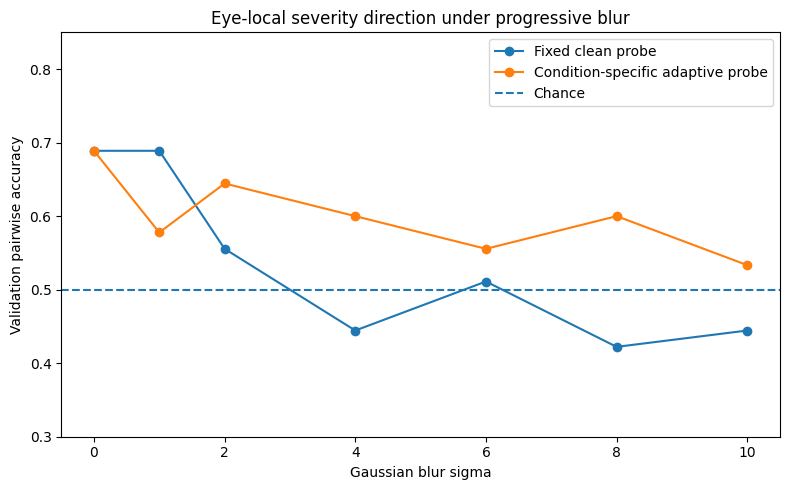


================ BLUR DOSE-RESPONSE RESULTS ================


,sigma,fixed_correct_pairs,fixed_accuracy,fixed_directional_auc,fixed_one_sided_p,fixed_minus_clean_accuracy,fixed_difference_ci_lower,fixed_difference_ci_upper,fixed_mcnemar_p,adaptive_selected_C,adaptive_correct_pairs,adaptive_accuracy,adaptive_directional_auc,adaptive_one_sided_p,adaptive_minus_clean_accuracy,adaptive_difference_ci_lower,adaptive_difference_ci_upper,adaptive_mcnemar_p
0,0.0,31,0.688889,0.753036,0.008047,0.000000,0.000000,0.000000,1.000000,0.00100,31,0.688889,0.753036,0.008047,0.000000,0.000000,0.000000,1.000000
1,1.0,31,0.688889,0.753036,0.008047,0.000000,-0.155556,0.155556,1.000000,0.10000,26,0.577778,0.603239,0.185649,-0.111111,-0.244444,0.022222,0.226562
2,2.0,25,0.555556,0.572874,0.275742,-0.133333,-0.355556,0.088889,0.344928,0.00003,29,0.644444,0.635628,0.036227,-0.044444,-0.222222,0.133333,0.803619
3,4.0,20,0.444444,0.400810,0.814351,-0.244444,-0.422222,-0.066667,0.026604,0.10000,27,0.600000,0.633603,0.116347,-0.088889,-0.288889,0.111111,0.503445
4,6.0,23,0.511111,0.431174,0.500000,-0.177778,-0.377778,0.022222,0.151590,0.00001,25,0.555556,0.536437,0.275742,-0.133333,-0.311111,0.066667,0.263176
5,8.0,19,0.422222,0.447368,0.883653,-0.266667,-0.466667,-0.066667,0.022656,0.00100,27,0.600000,0.554656,0.116347,-0.088889,-0.266667,0.088889,0.480682
6,10.0,20,0.444444,0.441296,0.814351,-0.244444,-0.444444,-0.044444,0.034690,0.10000,24,0.533333,0.510121,0.382996,-0.155556,-0.333333,0.022222,0.167068



First descriptive fixed-probe loss sigma: 2.0
First descriptive adaptive-probe loss sigma: 1.0

Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage2_Blur_Dose_Response_Summary.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage2_Blur_Dose_Response_All_Predictions.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage2_Blur_Dose_Response_Details.json
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage2_Blur_Dose_Response_Accuracy.png

Stage 2 blur dose-response evaluation passed.


In [12]:
#@title 02.2 Evaluate fixed and adaptive blur dose-response

from pathlib import Path
from scipy.stats import binomtest

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 20260719

PAIR_C_GRID = [
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
]


# ------------------------------------------------------------
# 1. Restore paths and blur matrices if runtime was reset
# ------------------------------------------------------------

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability"
    )

if "BASELINE_ROOT" not in globals():
    BASELINE_ROOT = (
        PROJECT_ROOT
        / "06_Data_Records"
        / "Retinal_DR"
        / "Frozen_Representation_Baseline_v0.1"
    )

if "KILL_TEST_ROOT" not in globals():
    KILL_TEST_ROOT = (
        PROJECT_ROOT
        / "06_Data_Records"
        / "Retinal_DR"
        / "Locality_Kill_Test_v0.1"
    )

if "FINE_STRUCTURE_ROOT" not in globals():
    FINE_STRUCTURE_ROOT = (
        PROJECT_ROOT
        / "06_Data_Records"
        / "Retinal_DR"
        / "Fine_Structure_Dissection_v0.1"
    )

FINE_STRUCTURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

SEALED_CLEAN_PROBE_PATH = (
    BASELINE_ROOT
    / "Ordinal_PairedDifference_Probe.joblib"
)

BASELINE_PAIR_PREDICTIONS_PATH = (
    BASELINE_ROOT
    / "Validation_Ordinal_PairedDifference_Predictions.csv"
)

PRIOR_SIGMA10_PATH = (
    KILL_TEST_ROOT
    / "ResNet50_ImageNet1K_V2_strong_blur_ImageEmbeddings_float32.npy"
)

required_paths = [
    IMAGE_INDEX_PATH,
    CLEAN_EMBEDDING_PATH,
    SEALED_CLEAN_PROBE_PATH,
    BASELINE_PAIR_PREDICTIONS_PATH,
    PRIOR_SIGMA10_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required files:\n"
        + "\n".join(map(str, missing_paths))
    )


if "image_meta_stage2" not in globals():
    image_meta_stage2 = pd.read_csv(
        IMAGE_INDEX_PATH
    )

    image_meta_stage2 = (
        image_meta_stage2
        .sort_values("embedding_row")
        .reset_index(drop=True)
        .copy()
    )


if "blur_image_embeddings" not in globals():
    blur_image_embeddings = {
        0.0: np.load(
            CLEAN_EMBEDDING_PATH
        )
    }

    for sigma in [
        1.0,
        2.0,
        4.0,
        6.0,
        8.0,
    ]:
        sigma_path = (
            FINE_STRUCTURE_ROOT
            / (
                "ResNet50_ImageNet1K_V2_"
                f"blur_sigma_{int(sigma)}_"
                "ImageEmbeddings_float32.npy"
            )
        )

        assert sigma_path.is_file(), sigma_path

        blur_image_embeddings[
            sigma
        ] = np.load(
            sigma_path
        )

    blur_image_embeddings[
        10.0
    ] = np.load(
        PRIOR_SIGMA10_PATH
    )


BLUR_SIGMAS_WITH_CLEAN = [
    0.0,
    1.0,
    2.0,
    4.0,
    6.0,
    8.0,
    10.0,
]

for sigma in BLUR_SIGMAS_WITH_CLEAN:
    matrix = blur_image_embeddings[
        sigma
    ]

    assert matrix.shape == (
        1600,
        2048,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()


# ------------------------------------------------------------
# 2. Freeze metadata alignment
# ------------------------------------------------------------

image_meta_stage2 = (
    image_meta_stage2
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

image_meta_stage2["patient_id"] = (
    image_meta_stage2["patient_id"]
    .astype(str)
)

assert np.array_equal(
    image_meta_stage2[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)


def canonical_eye_name(value):
    value = str(value).strip().lower()

    if value.startswith("l"):
        return "L"

    if value.startswith("r"):
        return "R"

    raise ValueError(
        f"Unrecognised eye label: {value}"
    )


image_meta_stage2["canonical_eye"] = (
    image_meta_stage2[
        "eye_resolved"
    ].map(canonical_eye_name)
)


# ------------------------------------------------------------
# 3. Construct a fixed eye definition
# ------------------------------------------------------------

eye_definition_records = []

for (
    split_name,
    patient_id,
    eye_name,
), row_indices in image_meta_stage2.groupby(
    [
        "split",
        "patient_id",
        "canonical_eye",
    ],
    sort=False,
).groups.items():

    row_indices = np.asarray(
        list(row_indices),
        dtype=int,
    )

    group = image_meta_stage2.iloc[
        row_indices
    ]

    grades = (
        group["eye_DR_Level"]
        .dropna()
        .astype(int)
        .unique()
    )

    if len(row_indices) != 2:
        raise ValueError(
            f"{split_name}, patient={patient_id}, "
            f"eye={eye_name}: found "
            f"{len(row_indices)} views."
        )

    if len(grades) != 1:
        raise ValueError(
            f"Inconsistent grades: {grades}"
        )

    eye_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "canonical_eye": eye_name,
            "eye_DR_Level": int(
                grades[0]
            ),
            "image_row_1": int(
                row_indices[0]
            ),
            "image_row_2": int(
                row_indices[1]
            ),
        }
    )


eye_definition = pd.DataFrame(
    eye_definition_records
)

eye_definition["eye_row"] = np.arange(
    len(eye_definition)
)

assert len(eye_definition) == 800

assert (
    eye_definition
    .groupby(
        [
            "split",
            "patient_id",
        ]
    )
    .size()
    .eq(2)
    .all()
)


# ------------------------------------------------------------
# 4. Construct the fixed unequal-grade patient definition
# ------------------------------------------------------------

pair_definition_records = []

for (
    split_name,
    patient_id,
), patient_group in eye_definition.groupby(
    [
        "split",
        "patient_id",
    ],
    sort=False,
):
    left_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("L")
    ]

    right_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("R")
    ]

    if (
        len(left_eye) != 1
        or len(right_eye) != 1
    ):
        raise ValueError(
            f"Could not resolve both eyes for "
            f"{split_name}, patient={patient_id}."
        )

    left_eye = left_eye.iloc[0]
    right_eye = right_eye.iloc[0]

    left_grade = int(
        left_eye["eye_DR_Level"]
    )

    right_grade = int(
        right_eye["eye_DR_Level"]
    )

    if left_grade == right_grade:
        continue

    pair_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "left_eye_row": int(
                left_eye["eye_row"]
            ),
            "right_eye_row": int(
                right_eye["eye_row"]
            ),
            "left_grade": left_grade,
            "right_grade": right_grade,
            "left_higher_grade": int(
                left_grade > right_grade
            ),
            "absolute_grade_gap": abs(
                left_grade
                - right_grade
            ),
            "binary_referable_discordant": int(
                (left_grade >= 2)
                != (right_grade >= 2)
            ),
        }
    )


pair_definition = pd.DataFrame(
    pair_definition_records
)

training_pair_mask = (
    pair_definition["split"]
    .eq("training")
    .to_numpy()
)

validation_pair_mask = (
    pair_definition["split"]
    .eq("validation")
    .to_numpy()
)

training_pair_definition = (
    pair_definition.loc[
        training_pair_mask
    ]
    .reset_index(drop=True)
    .copy()
)

validation_pair_definition = (
    pair_definition.loc[
        validation_pair_mask
    ]
    .reset_index(drop=True)
    .copy()
)

assert len(training_pair_definition) == 134
assert len(validation_pair_definition) == 45

y_all = (
    pair_definition[
        "left_higher_grade"
    ].to_numpy(dtype=int)
)

y_train = y_all[
    training_pair_mask
]

y_validation = y_all[
    validation_pair_mask
]

print(
    "Training unequal-grade patients:",
    len(y_train),
)

print(
    "Validation unequal-grade patients:",
    len(y_validation),
)


# ------------------------------------------------------------
# 5. Feature construction
# ------------------------------------------------------------

def build_eye_embeddings(
    image_embedding_matrix,
):
    eye_embeddings = np.empty(
        (
            len(eye_definition),
            image_embedding_matrix.shape[1],
        ),
        dtype=np.float32,
    )

    for row in eye_definition.itertuples(
        index=False
    ):
        eye_embeddings[
            row.eye_row
        ] = (
            image_embedding_matrix[
                [
                    row.image_row_1,
                    row.image_row_2,
                ]
            ]
            .mean(axis=0)
        )

    assert np.isfinite(
        eye_embeddings
    ).all()

    return eye_embeddings


def build_pair_features(
    image_embedding_matrix,
):
    eye_embeddings = build_eye_embeddings(
        image_embedding_matrix
    )

    left_rows = (
        pair_definition[
            "left_eye_row"
        ].to_numpy(dtype=int)
    )

    right_rows = (
        pair_definition[
            "right_eye_row"
        ].to_numpy(dtype=int)
    )

    pair_features = (
        eye_embeddings[left_rows]
        - eye_embeddings[right_rows]
    ).astype(np.float32)

    return pair_features


# ------------------------------------------------------------
# 6. Adaptive probe helpers
# ------------------------------------------------------------

def symmetrically_augment(
    feature_matrix,
    labels,
):
    return (
        np.concatenate(
            [
                feature_matrix,
                -feature_matrix,
            ],
            axis=0,
        ),
        np.concatenate(
            [
                labels,
                1 - labels,
            ],
            axis=0,
        ),
    )


def make_paired_probe(C_value):
    return Pipeline(
        steps=[
            (
                "standardize",
                StandardScaler(
                    with_mean=False
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=False,
                    max_iter=10000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


def select_C_using_training_only(
    X_train,
    labels,
):
    rows = []

    for C_value in PAIR_C_GRID:
        fold_accuracy = []
        fold_balanced_accuracy = []
        fold_auc = []

        splitter = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        )

        for (
            fold_train_indices,
            fold_test_indices,
        ) in splitter.split(
            X_train,
            labels,
        ):
            (
                augmented_features,
                augmented_labels,
            ) = symmetrically_augment(
                X_train[
                    fold_train_indices
                ],
                labels[
                    fold_train_indices
                ],
            )

            model = make_paired_probe(
                C_value
            )

            model.fit(
                augmented_features,
                augmented_labels,
            )

            probabilities = (
                model.predict_proba(
                    X_train[
                        fold_test_indices
                    ]
                )[:, 1]
            )

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            fold_labels = labels[
                fold_test_indices
            ]

            fold_accuracy.append(
                accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_balanced_accuracy.append(
                balanced_accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_auc.append(
                roc_auc_score(
                    fold_labels,
                    probabilities,
                )
            )

        rows.append(
            {
                "C": C_value,
                "mean_cv_accuracy": float(
                    np.mean(
                        fold_accuracy
                    )
                ),
                "sd_cv_accuracy": float(
                    np.std(
                        fold_accuracy,
                        ddof=1,
                    )
                ),
                "mean_cv_balanced_accuracy": float(
                    np.mean(
                        fold_balanced_accuracy
                    )
                ),
                "sd_cv_balanced_accuracy": float(
                    np.std(
                        fold_balanced_accuracy,
                        ddof=1,
                    )
                ),
                "mean_cv_auc": float(
                    np.mean(
                        fold_auc
                    )
                ),
            }
        )

    results = pd.DataFrame(
        rows
    )

    results = (
        results
        .sort_values(
            by=[
                "mean_cv_balanced_accuracy",
                "mean_cv_accuracy",
                "C",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    return (
        float(results.loc[0, "C"]),
        results,
    )


# ------------------------------------------------------------
# 7. Metric helpers
# ------------------------------------------------------------

def exact_accuracy_statistics(
    labels,
    predictions,
):
    correct = (
        predictions == labels
    ).astype(int)

    correct_pairs = int(
        correct.sum()
    )

    number_of_pairs = int(
        len(correct)
    )

    exact_test = binomtest(
        k=correct_pairs,
        n=number_of_pairs,
        p=0.5,
        alternative="greater",
    )

    exact_ci = binomtest(
        k=correct_pairs,
        n=number_of_pairs,
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    return {
        "correct": correct,
        "correct_pairs": correct_pairs,
        "accuracy": float(
            correct.mean()
        ),
        "ci_lower": float(
            exact_ci.low
        ),
        "ci_upper": float(
            exact_ci.high
        ),
        "one_sided_p": float(
            exact_test.pvalue
        ),
    }


def paired_accuracy_bootstrap(
    clean_correct,
    condition_correct,
    number_of_bootstraps=20000,
    random_seed=RANDOM_SEED,
):
    clean_correct = np.asarray(
        clean_correct,
        dtype=float,
    )

    condition_correct = np.asarray(
        condition_correct,
        dtype=float,
    )

    differences = (
        condition_correct
        - clean_correct
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_values = np.empty(
        number_of_bootstraps,
        dtype=float,
    )

    for bootstrap_index in range(
        number_of_bootstraps
    ):
        sampled_indices = rng.integers(
            low=0,
            high=len(differences),
            size=len(differences),
        )

        bootstrap_values[
            bootstrap_index
        ] = differences[
            sampled_indices
        ].mean()

    return {
        "estimate": float(
            differences.mean()
        ),
        "lower": float(
            np.percentile(
                bootstrap_values,
                2.5,
            )
        ),
        "upper": float(
            np.percentile(
                bootstrap_values,
                97.5,
            )
        ),
    }


def exact_mcnemar_test(
    clean_correct,
    condition_correct,
):
    clean_correct = np.asarray(
        clean_correct,
        dtype=int,
    )

    condition_correct = np.asarray(
        condition_correct,
        dtype=int,
    )

    clean_only_correct = int(
        (
            (clean_correct == 1)
            &
            (condition_correct == 0)
        ).sum()
    )

    condition_only_correct = int(
        (
            (clean_correct == 0)
            &
            (condition_correct == 1)
        ).sum()
    )

    discordant = (
        clean_only_correct
        + condition_only_correct
    )

    if discordant > 0:
        p_value = float(
            binomtest(
                k=condition_only_correct,
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )

    else:
        p_value = 1.0

    return {
        "clean_only_correct": (
            clean_only_correct
        ),
        "condition_only_correct": (
            condition_only_correct
        ),
        "p_value": p_value,
    }


# ------------------------------------------------------------
# 8. Load the unchanged clean probe
# ------------------------------------------------------------

sealed_clean_probe = joblib.load(
    SEALED_CLEAN_PROBE_PATH
)


# ------------------------------------------------------------
# 9. Evaluate every sigma
# ------------------------------------------------------------

dose_summary_rows = []
all_prediction_tables = []
adaptive_cv_results = {}

fixed_clean_correct = None
adaptive_clean_correct = None

for sigma_index, sigma in enumerate(
    BLUR_SIGMAS_WITH_CLEAN
):
    print(
        f"\nEvaluating blur sigma={sigma:g}"
    )

    pair_features = build_pair_features(
        blur_image_embeddings[
            sigma
        ]
    )

    X_train = pair_features[
        training_pair_mask
    ]

    X_validation = pair_features[
        validation_pair_mask
    ]

    # --------------------------------------------------------
    # Fixed sealed clean probe
    # --------------------------------------------------------

    fixed_probability = (
        sealed_clean_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    fixed_prediction = (
        fixed_probability >= 0.5
    ).astype(int)

    fixed_decision = (
        sealed_clean_probe.decision_function(
            X_validation
        )
    )

    fixed_stats = exact_accuracy_statistics(
        labels=y_validation,
        predictions=fixed_prediction,
    )

    fixed_balanced_accuracy = float(
        balanced_accuracy_score(
            y_validation,
            fixed_prediction,
        )
    )

    fixed_auc = float(
        roc_auc_score(
            y_validation,
            fixed_probability,
        )
    )

    # --------------------------------------------------------
    # Condition-specific adaptive probe
    # --------------------------------------------------------

    best_C, cv_results = (
        select_C_using_training_only(
            X_train=X_train,
            labels=y_train,
        )
    )

    adaptive_cv_results[
        sigma
    ] = cv_results

    (
        augmented_features,
        augmented_labels,
    ) = symmetrically_augment(
        X_train,
        y_train,
    )

    adaptive_probe = make_paired_probe(
        best_C
    )

    adaptive_probe.fit(
        augmented_features,
        augmented_labels,
    )

    adaptive_probability = (
        adaptive_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    adaptive_prediction = (
        adaptive_probability >= 0.5
    ).astype(int)

    adaptive_decision = (
        adaptive_probe.decision_function(
            X_validation
        )
    )

    adaptive_stats = (
        exact_accuracy_statistics(
            labels=y_validation,
            predictions=adaptive_prediction,
        )
    )

    adaptive_balanced_accuracy = float(
        balanced_accuracy_score(
            y_validation,
            adaptive_prediction,
        )
    )

    adaptive_auc = float(
        roc_auc_score(
            y_validation,
            adaptive_probability,
        )
    )

    # --------------------------------------------------------
    # Paired comparisons against sigma=0
    # --------------------------------------------------------

    if sigma == 0:
        fixed_clean_correct = (
            fixed_stats["correct"].copy()
        )

        adaptive_clean_correct = (
            adaptive_stats["correct"].copy()
        )

        fixed_difference = {
            "estimate": 0.0,
            "lower": 0.0,
            "upper": 0.0,
        }

        adaptive_difference = {
            "estimate": 0.0,
            "lower": 0.0,
            "upper": 0.0,
        }

        fixed_mcnemar = {
            "clean_only_correct": 0,
            "condition_only_correct": 0,
            "p_value": 1.0,
        }

        adaptive_mcnemar = {
            "clean_only_correct": 0,
            "condition_only_correct": 0,
            "p_value": 1.0,
        }

    else:
        fixed_difference = (
            paired_accuracy_bootstrap(
                clean_correct=(
                    fixed_clean_correct
                ),
                condition_correct=(
                    fixed_stats["correct"]
                ),
                number_of_bootstraps=20000,
                random_seed=(
                    RANDOM_SEED
                    + 300
                    + sigma_index
                ),
            )
        )

        adaptive_difference = (
            paired_accuracy_bootstrap(
                clean_correct=(
                    adaptive_clean_correct
                ),
                condition_correct=(
                    adaptive_stats["correct"]
                ),
                number_of_bootstraps=20000,
                random_seed=(
                    RANDOM_SEED
                    + 400
                    + sigma_index
                ),
            )
        )

        fixed_mcnemar = (
            exact_mcnemar_test(
                clean_correct=(
                    fixed_clean_correct
                ),
                condition_correct=(
                    fixed_stats["correct"]
                ),
            )
        )

        adaptive_mcnemar = (
            exact_mcnemar_test(
                clean_correct=(
                    adaptive_clean_correct
                ),
                condition_correct=(
                    adaptive_stats["correct"]
                ),
            )
        )

    # --------------------------------------------------------
    # Save patient-level predictions
    # --------------------------------------------------------

    true_direction_sign = (
        2 * y_validation - 1
    )

    prediction_table = (
        validation_pair_definition
        .copy()
    )

    prediction_table["sigma"] = float(
        sigma
    )

    prediction_table[
        "fixed_probability_left_higher"
    ] = fixed_probability

    prediction_table[
        "fixed_predicted_left_higher"
    ] = fixed_prediction

    prediction_table[
        "fixed_correct"
    ] = fixed_stats["correct"]

    prediction_table[
        "fixed_true_signed_margin"
    ] = (
        fixed_decision
        * true_direction_sign
    )

    prediction_table[
        "adaptive_probability_left_higher"
    ] = adaptive_probability

    prediction_table[
        "adaptive_predicted_left_higher"
    ] = adaptive_prediction

    prediction_table[
        "adaptive_correct"
    ] = adaptive_stats["correct"]

    prediction_table[
        "adaptive_true_signed_margin"
    ] = (
        adaptive_decision
        * true_direction_sign
    )

    all_prediction_tables.append(
        prediction_table
    )

    dose_summary_rows.append(
        {
            "sigma": float(sigma),

            "fixed_correct_pairs": (
                fixed_stats["correct_pairs"]
            ),
            "fixed_accuracy": (
                fixed_stats["accuracy"]
            ),
            "fixed_accuracy_ci_lower": (
                fixed_stats["ci_lower"]
            ),
            "fixed_accuracy_ci_upper": (
                fixed_stats["ci_upper"]
            ),
            "fixed_balanced_accuracy": (
                fixed_balanced_accuracy
            ),
            "fixed_directional_auc": (
                fixed_auc
            ),
            "fixed_one_sided_p": (
                fixed_stats["one_sided_p"]
            ),
            "fixed_minus_clean_accuracy": (
                fixed_difference["estimate"]
            ),
            "fixed_difference_ci_lower": (
                fixed_difference["lower"]
            ),
            "fixed_difference_ci_upper": (
                fixed_difference["upper"]
            ),
            "fixed_clean_only_correct": (
                fixed_mcnemar[
                    "clean_only_correct"
                ]
            ),
            "fixed_condition_only_correct": (
                fixed_mcnemar[
                    "condition_only_correct"
                ]
            ),
            "fixed_mcnemar_p": (
                fixed_mcnemar["p_value"]
            ),

            "adaptive_selected_C": float(
                best_C
            ),
            "adaptive_best_cv_balanced_accuracy": float(
                cv_results.loc[
                    0,
                    "mean_cv_balanced_accuracy",
                ]
            ),
            "adaptive_correct_pairs": (
                adaptive_stats[
                    "correct_pairs"
                ]
            ),
            "adaptive_accuracy": (
                adaptive_stats["accuracy"]
            ),
            "adaptive_accuracy_ci_lower": (
                adaptive_stats["ci_lower"]
            ),
            "adaptive_accuracy_ci_upper": (
                adaptive_stats["ci_upper"]
            ),
            "adaptive_balanced_accuracy": (
                adaptive_balanced_accuracy
            ),
            "adaptive_directional_auc": (
                adaptive_auc
            ),
            "adaptive_one_sided_p": (
                adaptive_stats[
                    "one_sided_p"
                ]
            ),
            "adaptive_minus_clean_accuracy": (
                adaptive_difference[
                    "estimate"
                ]
            ),
            "adaptive_difference_ci_lower": (
                adaptive_difference[
                    "lower"
                ]
            ),
            "adaptive_difference_ci_upper": (
                adaptive_difference[
                    "upper"
                ]
            ),
            "adaptive_clean_only_correct": (
                adaptive_mcnemar[
                    "clean_only_correct"
                ]
            ),
            "adaptive_condition_only_correct": (
                adaptive_mcnemar[
                    "condition_only_correct"
                ]
            ),
            "adaptive_mcnemar_p": (
                adaptive_mcnemar[
                    "p_value"
                ]
            ),
        }
    )

    print(
        "  Fixed:",
        f"{fixed_stats['correct_pairs']}/45,",
        f"AUC={fixed_auc:.4f}",
    )

    print(
        "  Adaptive:",
        f"{adaptive_stats['correct_pairs']}/45,",
        f"AUC={adaptive_auc:.4f},",
        f"C={best_C:g}",
    )


# ------------------------------------------------------------
# 10. Validate clean reproduction
# ------------------------------------------------------------

blur_dose_summary = pd.DataFrame(
    dose_summary_rows
)

clean_row = blur_dose_summary.loc[
    blur_dose_summary["sigma"].eq(0)
].iloc[0]

assert int(
    clean_row["fixed_correct_pairs"]
) == 31

assert np.isclose(
    clean_row["fixed_accuracy"],
    31 / 45,
)

assert int(
    clean_row["adaptive_correct_pairs"]
) == 31

assert np.isclose(
    clean_row["adaptive_accuracy"],
    31 / 45,
)

print(
    "\nClean baseline reproduced exactly."
)


# ------------------------------------------------------------
# 11. Save all artifacts
# ------------------------------------------------------------

blur_dose_predictions = pd.concat(
    all_prediction_tables,
    ignore_index=True,
)

BLUR_DOSE_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Summary.csv"
)

BLUR_DOSE_PREDICTIONS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_All_Predictions.csv"
)

BLUR_DOSE_DETAILS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Details.json"
)

BLUR_DOSE_FIGURE_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Accuracy.png"
)

blur_dose_summary.to_csv(
    BLUR_DOSE_SUMMARY_PATH,
    index=False,
)

blur_dose_predictions.to_csv(
    BLUR_DOSE_PREDICTIONS_PATH,
    index=False,
)

for sigma, cv_results in (
    adaptive_cv_results.items()
):
    sigma_text = (
        "clean"
        if sigma == 0
        else f"sigma_{int(sigma)}"
    )

    cv_results.to_csv(
        FINE_STRUCTURE_ROOT
        / (
            "Stage2_Blur_"
            f"{sigma_text}_AdaptiveProbe_CV.csv"
        ),
        index=False,
    )


# ------------------------------------------------------------
# 12. Descriptive thresholds
# ------------------------------------------------------------

nonzero_rows = blur_dose_summary.loc[
    blur_dose_summary["sigma"] > 0
].sort_values("sigma")

fixed_loss_rows = nonzero_rows.loc[
    (
        nonzero_rows[
            "fixed_one_sided_p"
        ] >= 0.05
    )
    |
    (
        nonzero_rows[
            "fixed_directional_auc"
        ] < 0.60
    )
]

adaptive_loss_rows = nonzero_rows.loc[
    (
        nonzero_rows[
            "adaptive_one_sided_p"
        ] >= 0.05
    )
    |
    (
        nonzero_rows[
            "adaptive_directional_auc"
        ] < 0.60
    )
]

first_fixed_loss_sigma = (
    float(
        fixed_loss_rows.iloc[
            0
        ]["sigma"]
    )
    if len(fixed_loss_rows) > 0
    else None
)

first_adaptive_loss_sigma = (
    float(
        adaptive_loss_rows.iloc[
            0
        ]["sigma"]
    )
    if len(adaptive_loss_rows) > 0
    else None
)

details = {
    "validation_patients": 45,
    "training_patients": 134,
    "blur_sigmas": (
        BLUR_SIGMAS_WITH_CLEAN
    ),
    "first_descriptive_fixed_loss_sigma": (
        first_fixed_loss_sigma
    ),
    "first_descriptive_adaptive_loss_sigma": (
        first_adaptive_loss_sigma
    ),
    "loss_definition": (
        "one-sided p >= 0.05 or "
        "directional AUC < 0.60"
    ),
    "note": (
        "Thresholds are descriptive and were not "
        "used to tune the perturbation strengths."
    ),
}

with open(
    BLUR_DOSE_DETAILS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        details,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 13. Plot accuracy dose-response
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(8, 5)
)

axis.plot(
    blur_dose_summary["sigma"],
    blur_dose_summary["fixed_accuracy"],
    marker="o",
    label="Fixed clean probe",
)

axis.plot(
    blur_dose_summary["sigma"],
    blur_dose_summary["adaptive_accuracy"],
    marker="o",
    label="Condition-specific adaptive probe",
)

axis.axhline(
    0.5,
    linestyle="--",
    label="Chance",
)

axis.set_xlabel(
    "Gaussian blur sigma"
)

axis.set_ylabel(
    "Validation pairwise accuracy"
)

axis.set_ylim(
    0.30,
    0.85,
)

axis.set_title(
    "Eye-local severity direction under progressive blur"
)

axis.legend()

figure.tight_layout()

figure.savefig(
    BLUR_DOSE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ------------------------------------------------------------
# 14. Final report
# ------------------------------------------------------------

print(
    "\n================ BLUR DOSE-RESPONSE "
    "RESULTS ================"
)

display(
    blur_dose_summary[
        [
            "sigma",
            "fixed_correct_pairs",
            "fixed_accuracy",
            "fixed_directional_auc",
            "fixed_one_sided_p",
            "fixed_minus_clean_accuracy",
            "fixed_difference_ci_lower",
            "fixed_difference_ci_upper",
            "fixed_mcnemar_p",
            "adaptive_selected_C",
            "adaptive_correct_pairs",
            "adaptive_accuracy",
            "adaptive_directional_auc",
            "adaptive_one_sided_p",
            "adaptive_minus_clean_accuracy",
            "adaptive_difference_ci_lower",
            "adaptive_difference_ci_upper",
            "adaptive_mcnemar_p",
        ]
    ]
)

print(
    "\nFirst descriptive fixed-probe loss sigma:",
    first_fixed_loss_sigma,
)

print(
    "First descriptive adaptive-probe loss sigma:",
    first_adaptive_loss_sigma,
)

print("\nSaved:")
print(BLUR_DOSE_SUMMARY_PATH)
print(BLUR_DOSE_PREDICTIONS_PATH)
print(BLUR_DOSE_DETAILS_PATH)
print(BLUR_DOSE_FIGURE_PATH)

print(
    "\nStage 2 blur dose-response "
    "evaluation passed."
)

In [14]:
#@title 03.1 Extract and cache edge-only / high-pass embeddings

from google.colab import drive
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
)
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode


# ------------------------------------------------------------
# 1. Safely resolve the active Google Drive mount
# ------------------------------------------------------------

if Path("/content/gdrive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

elif Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

else:
    drive.mount(
        "/content/gdrive",
        force_remount=True,
    )

    DRIVE_ROOT = Path(
        "/content/gdrive/MyDrive"
    )

assert DRIVE_ROOT.is_dir(), DRIVE_ROOT

PROJECT_ROOT = (
    DRIVE_ROOT
    / "Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)

FINE_STRUCTURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

assert IMAGE_INDEX_PATH.is_file(), IMAGE_INDEX_PATH
assert CLEAN_EMBEDDING_PATH.is_file(), CLEAN_EMBEDDING_PATH


# ------------------------------------------------------------
# 2. Load and freeze row alignment
# ------------------------------------------------------------

image_meta_stage3 = pd.read_csv(
    IMAGE_INDEX_PATH
)

image_meta_stage3 = (
    image_meta_stage3
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

assert len(image_meta_stage3) == 1600

assert np.array_equal(
    image_meta_stage3[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)

clean_image_embeddings = np.load(
    CLEAN_EMBEDDING_PATH
)

assert clean_image_embeddings.shape == (
    1600,
    2048,
)

assert clean_image_embeddings.dtype == np.float32
assert np.isfinite(clean_image_embeddings).all()


# ------------------------------------------------------------
# 3. Repair stored Colab paths when Drive is mounted elsewhere
# ------------------------------------------------------------

def resolve_image_path(stored_path):
    stored_path = str(stored_path)

    known_prefixes = [
        "/content/drive/MyDrive/",
        "/content/gdrive/MyDrive/",
    ]

    for prefix in known_prefixes:
        if stored_path.startswith(prefix):
            relative_path = stored_path[
                len(prefix):
            ]

            return DRIVE_ROOT / relative_path

    candidate = Path(stored_path)

    if candidate.is_file():
        return candidate

    raise FileNotFoundError(
        f"Could not resolve stored image path: "
        f"{stored_path}"
    )


resolved_image_paths = [
    resolve_image_path(path)
    for path in image_meta_stage3[
        "image_path_disk"
    ]
]

missing_images = [
    path
    for path in resolved_image_paths
    if not path.is_file()
]

assert not missing_images, (
    f"Missing images: {len(missing_images)}"
)

image_meta_stage3[
    "resolved_image_path"
] = [
    str(path)
    for path in resolved_image_paths
]

print("Resolved images:", len(resolved_image_paths))
print("Drive root:", DRIVE_ROOT)


# ------------------------------------------------------------
# 4. Runtime and exact frozen encoder
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nPyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

assert device.type == "cuda", (
    "Please use the T4 GPU runtime."
)

weights = ResNet50_Weights.IMAGENET1K_V2

encoder = resnet50(
    weights=weights
)

embedding_dim = encoder.fc.in_features
encoder.fc = nn.Identity()

encoder.eval()

for parameter in encoder.parameters():
    parameter.requires_grad = False

encoder = encoder.to(device)

assert embedding_dim == 2048

assert sum(
    parameter.numel()
    for parameter in encoder.parameters()
    if parameter.requires_grad
) == 0

print("Frozen encoder ready.")


# ------------------------------------------------------------
# 5. Spatial preprocessing
# ------------------------------------------------------------

resize_transform = transforms.Resize(
    232,
    interpolation=InterpolationMode.BILINEAR,
    antialias=True,
)

crop_transform = transforms.CenterCrop(
    224
)

to_tensor_transform = transforms.ToTensor()

normalise_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
)


def prepare_crop(image):
    image = resize_transform(image)
    image = crop_transform(image)
    return image


def rgb_to_grayscale_tensor(rgb_tensor):
    red = rgb_tensor[0:1]
    green = rgb_tensor[1:2]
    blue = rgb_tensor[2:3]

    grayscale = (
        0.2989 * red
        + 0.5870 * green
        + 0.1140 * blue
    )

    return grayscale


# ------------------------------------------------------------
# 6. Edge and high-pass transforms
# ------------------------------------------------------------

SOBEL_X = torch.tensor(
    [
        [-1.0, 0.0, 1.0],
        [-2.0, 0.0, 2.0],
        [-1.0, 0.0, 1.0],
    ],
    dtype=torch.float32,
).reshape(1, 1, 3, 3) / 8.0

SOBEL_Y = torch.tensor(
    [
        [-1.0, -2.0, -1.0],
        [0.0, 0.0, 0.0],
        [1.0, 2.0, 1.0],
    ],
    dtype=torch.float32,
).reshape(1, 1, 3, 3) / 8.0


def robust_positive_normalise(
    tensor,
    quantile=0.99,
):
    scale = torch.quantile(
        tensor.flatten(),
        quantile,
    )

    scale = torch.clamp(
        scale,
        min=1e-6,
    )

    normalised = torch.clamp(
        tensor / scale,
        min=0.0,
        max=1.0,
    )

    return normalised, float(scale)


def robust_signed_normalise(
    tensor,
    quantile=0.99,
):
    scale = torch.quantile(
        tensor.abs().flatten(),
        quantile,
    )

    scale = torch.clamp(
        scale,
        min=1e-6,
    )

    # -scale -> 0, zero -> 0.5, +scale -> 1
    normalised = torch.clamp(
        0.5
        + 0.5 * tensor / scale,
        min=0.0,
        max=1.0,
    )

    return normalised, float(scale)


def create_condition_tensor(
    image,
    condition,
):
    image = prepare_crop(image)

    rgb_tensor = to_tensor_transform(
        image
    )

    grayscale = rgb_to_grayscale_tensor(
        rgb_tensor
    )

    if condition == "sobel_edges":
        grayscale_batch = grayscale.unsqueeze(
            0
        )

        gradient_x = F.conv2d(
            grayscale_batch,
            SOBEL_X,
            padding=1,
        )

        gradient_y = F.conv2d(
            grayscale_batch,
            SOBEL_Y,
            padding=1,
        )

        edge_magnitude = torch.sqrt(
            gradient_x**2
            + gradient_y**2
            + 1e-12
        ).squeeze(0)

        transformed, scale = (
            robust_positive_normalise(
                edge_magnitude,
                quantile=0.99,
            )
        )

    elif condition == "highpass_sigma2":
        low_frequency = TF.gaussian_blur(
            grayscale,
            kernel_size=[13, 13],
            sigma=[2.0, 2.0],
        )

        high_frequency = (
            grayscale
            - low_frequency
        )

        transformed, scale = (
            robust_signed_normalise(
                high_frequency,
                quantile=0.99,
            )
        )

    else:
        raise ValueError(
            f"Unknown condition: {condition}"
        )

    transformed_rgb = transformed.repeat(
        3,
        1,
        1,
    )

    transformed_rgb = normalise_transform(
        transformed_rgb
    )

    return transformed_rgb, scale


# ------------------------------------------------------------
# 7. Dataset
# ------------------------------------------------------------

class Stage3TransformDataset(Dataset):
    def __init__(
        self,
        metadata,
        condition,
    ):
        self.image_paths = (
            metadata[
                "resolved_image_path"
            ]
            .astype(str)
            .tolist()
        )

        self.condition = condition

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[
            index
        ]

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert("RGB")

                tensor, scale = (
                    create_condition_tensor(
                        image=image,
                        condition=self.condition,
                    )
                )

        except Exception as error:
            raise RuntimeError(
                f"Failed condition={self.condition}, "
                f"row={index}, path={image_path}"
            ) from error

        return (
            tensor,
            index,
            np.float32(scale),
        )


# ------------------------------------------------------------
# 8. Extract both pre-registered conditions
# ------------------------------------------------------------

STAGE3_CONDITIONS = [
    "sobel_edges",
    "highpass_sigma2",
]

BATCH_SIZE = 32

# Avoid Colab multiprocessing cleanup errors.
NUM_WORKERS = 2

stage3_image_embeddings = {
    "clean_cached": clean_image_embeddings
}

embedding_audit_rows = []
normalisation_scale_records = []

clean_norms = np.linalg.norm(
    clean_image_embeddings,
    axis=1,
)

encoder.eval()

for condition in STAGE3_CONDITIONS:
    output_path = (
        FINE_STRUCTURE_ROOT
        / (
            "ResNet50_ImageNet1K_V2_"
            f"{condition}_"
            "ImageEmbeddings_float32.npy"
        )
    )

    scale_path = (
        FINE_STRUCTURE_ROOT
        / (
            f"Stage3_{condition}_"
            "Normalisation_Scales.npy"
        )
    )

    if (
        output_path.is_file()
        and scale_path.is_file()
    ):
        print(
            f"\nLoading cached condition: "
            f"{condition}"
        )

        matrix = np.load(
            output_path
        )

        scales = np.load(
            scale_path
        )

    else:
        print(
            f"\nExtracting condition: "
            f"{condition}"
        )

        dataset = Stage3TransformDataset(
            metadata=image_meta_stage3,
            condition=condition,
        )

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True,
        )

        matrix = np.empty(
            (
                len(image_meta_stage3),
                embedding_dim,
            ),
            dtype=np.float32,
        )

        scales = np.empty(
            len(image_meta_stage3),
            dtype=np.float32,
        )

        with torch.inference_mode():
            for (
                image_batch,
                row_indices,
                batch_scales,
            ) in tqdm(
                loader,
                desc=condition,
            ):
                image_batch = image_batch.to(
                    device,
                    non_blocking=True,
                )

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=True,
                ):
                    batch_embeddings = encoder(
                        image_batch
                    )

                batch_embeddings = (
                    batch_embeddings
                    .float()
                    .cpu()
                    .numpy()
                )

                row_indices = (
                    row_indices
                    .numpy()
                )

                matrix[
                    row_indices
                ] = batch_embeddings

                scales[
                    row_indices
                ] = (
                    batch_scales
                    .numpy()
                    .astype(np.float32)
                )

        np.save(
            output_path,
            matrix,
            allow_pickle=False,
        )

        np.save(
            scale_path,
            scales,
            allow_pickle=False,
        )

        print("Saved embeddings:")
        print(output_path)

        print("Saved scales:")
        print(scale_path)

    assert matrix.shape == (
        1600,
        2048,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()

    assert scales.shape == (1600,)
    assert np.isfinite(scales).all()
    assert (scales > 0).all()

    stage3_image_embeddings[
        condition
    ] = matrix

    matrix_norms = np.linalg.norm(
        matrix,
        axis=1,
    )

    cosine_similarity = (
        np.sum(
            clean_image_embeddings
            * matrix,
            axis=1,
        )
        /
        np.maximum(
            clean_norms
            * matrix_norms,
            1e-12,
        )
    )

    l2_shift = np.linalg.norm(
        matrix
        - clean_image_embeddings,
        axis=1,
    )

    dimension_sd = matrix.std(
        axis=0
    )

    embedding_audit_rows.append(
        {
            "condition": condition,
            "rows": int(
                matrix.shape[0]
            ),
            "dimensions": int(
                matrix.shape[1]
            ),
            "mean_cosine_similarity_to_clean": float(
                cosine_similarity.mean()
            ),
            "median_cosine_similarity_to_clean": float(
                np.median(
                    cosine_similarity
                )
            ),
            "mean_l2_shift_from_clean": float(
                l2_shift.mean()
            ),
            "near_zero_variance_dimensions": int(
                (
                    dimension_sd
                    < 1e-8
                ).sum()
            ),
            "normalisation_scale_min": float(
                scales.min()
            ),
            "normalisation_scale_median": float(
                np.median(scales)
            ),
            "normalisation_scale_max": float(
                scales.max()
            ),
            "embedding_path": str(
                output_path
            ),
        }
    )

    for row_index, scale in enumerate(
        scales
    ):
        normalisation_scale_records.append(
            {
                "condition": condition,
                "embedding_row": row_index,
                "normalisation_scale": float(
                    scale
                ),
            }
        )


# ------------------------------------------------------------
# 9. Save audits
# ------------------------------------------------------------

stage3_embedding_audit = pd.DataFrame(
    embedding_audit_rows
)

stage3_scale_audit = pd.DataFrame(
    normalisation_scale_records
)

STAGE3_EMBEDDING_AUDIT_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Embedding_Audit.csv"
)

STAGE3_SCALE_AUDIT_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Normalisation_Scales.csv"
)

stage3_embedding_audit.to_csv(
    STAGE3_EMBEDDING_AUDIT_PATH,
    index=False,
)

stage3_scale_audit.to_csv(
    STAGE3_SCALE_AUDIT_PATH,
    index=False,
)


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print(
    "\n================ STAGE 3 EMBEDDING "
    "AUDIT ================"
)

display(
    stage3_embedding_audit[
        [
            "condition",
            "rows",
            "dimensions",
            "mean_cosine_similarity_to_clean",
            "median_cosine_similarity_to_clean",
            "mean_l2_shift_from_clean",
            "near_zero_variance_dimensions",
            "normalisation_scale_min",
            "normalisation_scale_median",
            "normalisation_scale_max",
        ]
    ]
)

print("\nSaved:")
print(STAGE3_EMBEDDING_AUDIT_PATH)
print(STAGE3_SCALE_AUDIT_PATH)

print(
    "\nStage 3 edge/high-pass embeddings "
    "passed integrity checks."
)

Resolved images: 1600
Drive root: /content/gdrive/MyDrive

PyTorch: 2.11.0+cu128
TorchVision: 0.26.0+cu128
Device: cuda
GPU: Tesla T4
Frozen encoder ready.

Extracting condition: sobel_edges


sobel_edges:   0%|          | 0/50 [00:00<?, ?it/s]

Saved embeddings:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_sobel_edges_ImageEmbeddings_float32.npy
Saved scales:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_sobel_edges_Normalisation_Scales.npy

Extracting condition: highpass_sigma2


highpass_sigma2:   0%|          | 0/50 [00:00<?, ?it/s]

Saved embeddings:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_highpass_sigma2_ImageEmbeddings_float32.npy
Saved scales:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_highpass_sigma2_Normalisation_Scales.npy

================ STAGE 3 EMBEDDING AUDIT ================


,condition,rows,dimensions,mean_cosine_similarity_to_clean,median_cosine_similarity_to_clean,mean_l2_shift_from_clean,near_zero_variance_dimensions,normalisation_scale_min,normalisation_scale_median,normalisation_scale_max
0,sobel_edges,1600,2048,0.474073,0.474814,14.556501,0,0.034017,0.142267,0.396330
1,highpass_sigma2,1600,2048,0.363472,0.356474,12.041232,14,0.023682,0.117873,0.278082



Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_Embedding_Audit.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_Normalisation_Scales.csv

Stage 3 edge/high-pass embeddings passed integrity checks.


In [15]:
#@title 03.2 Evaluate edge-only and high-pass locality information

from pathlib import Path
from scipy.stats import binomtest

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 20260719

PAIR_C_GRID = [
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
]


# ------------------------------------------------------------
# 1. Resolve current Drive mount and input files
# ------------------------------------------------------------

if Path("/content/gdrive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

elif Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

else:
    raise FileNotFoundError(
        "Google Drive is not mounted. "
        "Run the safe Drive recovery cell first."
    )


PROJECT_ROOT = (
    DRIVE_ROOT
    / "Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)

IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

SEALED_CLEAN_PROBE_PATH = (
    BASELINE_ROOT
    / "Ordinal_PairedDifference_Probe.joblib"
)

BASELINE_PAIR_PREDICTIONS_PATH = (
    BASELINE_ROOT
    / "Validation_Ordinal_PairedDifference_Predictions.csv"
)

SOBEL_EMBEDDING_PATH = (
    FINE_STRUCTURE_ROOT
    / "ResNet50_ImageNet1K_V2_sobel_edges_ImageEmbeddings_float32.npy"
)

HIGHPASS_EMBEDDING_PATH = (
    FINE_STRUCTURE_ROOT
    / "ResNet50_ImageNet1K_V2_highpass_sigma2_ImageEmbeddings_float32.npy"
)

required_paths = [
    IMAGE_INDEX_PATH,
    CLEAN_EMBEDDING_PATH,
    SEALED_CLEAN_PROBE_PATH,
    BASELINE_PAIR_PREDICTIONS_PATH,
    SOBEL_EMBEDDING_PATH,
    HIGHPASS_EMBEDDING_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing Stage 3 files:\n"
        + "\n".join(map(str, missing_paths))
    )


# ------------------------------------------------------------
# 2. Load aligned metadata and representations
# ------------------------------------------------------------

image_meta_stage3_eval = pd.read_csv(
    IMAGE_INDEX_PATH
)

image_meta_stage3_eval = (
    image_meta_stage3_eval
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

image_meta_stage3_eval["patient_id"] = (
    image_meta_stage3_eval["patient_id"]
    .astype(str)
)

assert len(image_meta_stage3_eval) == 1600

assert np.array_equal(
    image_meta_stage3_eval[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)


condition_matrices = {
    "clean_cached": np.load(
        CLEAN_EMBEDDING_PATH
    ),
    "sobel_edges": np.load(
        SOBEL_EMBEDDING_PATH
    ),
    "highpass_sigma2": np.load(
        HIGHPASS_EMBEDDING_PATH
    ),
}

for condition, matrix in condition_matrices.items():
    assert matrix.shape == (1600, 2048), (
        condition,
        matrix.shape,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()

print("Loaded conditions:")

for condition, matrix in condition_matrices.items():
    print(
        f"  {condition}: {matrix.shape}"
    )


# ------------------------------------------------------------
# 3. Resolve left and right eyes
# ------------------------------------------------------------

def canonical_eye_name(value):
    value = str(value).strip().lower()

    if value.startswith("l"):
        return "L"

    if value.startswith("r"):
        return "R"

    raise ValueError(
        f"Unrecognised eye label: {value}"
    )


image_meta_stage3_eval[
    "canonical_eye"
] = (
    image_meta_stage3_eval[
        "eye_resolved"
    ].map(canonical_eye_name)
)


# ------------------------------------------------------------
# 4. Build a fixed eye definition
# ------------------------------------------------------------

eye_definition_records = []

for (
    split_name,
    patient_id,
    eye_name,
), row_indices in image_meta_stage3_eval.groupby(
    [
        "split",
        "patient_id",
        "canonical_eye",
    ],
    sort=False,
).groups.items():

    row_indices = np.asarray(
        list(row_indices),
        dtype=int,
    )

    group = image_meta_stage3_eval.iloc[
        row_indices
    ]

    eye_grades = (
        group["eye_DR_Level"]
        .dropna()
        .astype(int)
        .unique()
    )

    if len(row_indices) != 2:
        raise ValueError(
            f"{split_name}, patient={patient_id}, "
            f"eye={eye_name}: expected two views, "
            f"found {len(row_indices)}."
        )

    if len(eye_grades) != 1:
        raise ValueError(
            f"Inconsistent eye grades: "
            f"{eye_grades}"
        )

    eye_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "canonical_eye": eye_name,
            "eye_DR_Level": int(
                eye_grades[0]
            ),
            "image_row_1": int(
                row_indices[0]
            ),
            "image_row_2": int(
                row_indices[1]
            ),
        }
    )


eye_definition = pd.DataFrame(
    eye_definition_records
)

eye_definition["eye_row"] = np.arange(
    len(eye_definition)
)

assert len(eye_definition) == 800

assert (
    eye_definition
    .groupby(
        [
            "split",
            "patient_id",
        ]
    )
    .size()
    .eq(2)
    .all()
)


# ------------------------------------------------------------
# 5. Freeze unequal-grade patient pairs
# ------------------------------------------------------------

pair_definition_records = []

for (
    split_name,
    patient_id,
), patient_group in eye_definition.groupby(
    [
        "split",
        "patient_id",
    ],
    sort=False,
):
    left_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("L")
    ]

    right_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("R")
    ]

    if (
        len(left_eye) != 1
        or len(right_eye) != 1
    ):
        raise ValueError(
            f"Could not resolve both eyes for "
            f"{split_name}, patient={patient_id}."
        )

    left_eye = left_eye.iloc[0]
    right_eye = right_eye.iloc[0]

    left_grade = int(
        left_eye["eye_DR_Level"]
    )

    right_grade = int(
        right_eye["eye_DR_Level"]
    )

    if left_grade == right_grade:
        continue

    pair_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "left_eye_row": int(
                left_eye["eye_row"]
            ),
            "right_eye_row": int(
                right_eye["eye_row"]
            ),
            "left_grade": left_grade,
            "right_grade": right_grade,
            "left_higher_grade": int(
                left_grade > right_grade
            ),
            "absolute_grade_gap": abs(
                left_grade - right_grade
            ),
            "binary_referable_discordant": int(
                (left_grade >= 2)
                != (right_grade >= 2)
            ),
        }
    )


pair_definition = pd.DataFrame(
    pair_definition_records
)

training_mask = (
    pair_definition["split"]
    .eq("training")
    .to_numpy()
)

validation_mask = (
    pair_definition["split"]
    .eq("validation")
    .to_numpy()
)

training_pair_definition = (
    pair_definition.loc[
        training_mask
    ]
    .reset_index(drop=True)
    .copy()
)

validation_pair_definition = (
    pair_definition.loc[
        validation_mask
    ]
    .reset_index(drop=True)
    .copy()
)

y_all = (
    pair_definition[
        "left_higher_grade"
    ].to_numpy(dtype=int)
)

y_train = y_all[
    training_mask
]

y_validation = y_all[
    validation_mask
]

assert len(y_train) == 134
assert len(y_validation) == 45

print(
    "\nTraining unequal-grade patients:",
    len(y_train),
)

print(
    "Validation unequal-grade patients:",
    len(y_validation),
)


# ------------------------------------------------------------
# 6. Construct eye and paired-difference features
# ------------------------------------------------------------

def build_pair_features(
    image_embedding_matrix,
):
    eye_embeddings = np.empty(
        (
            len(eye_definition),
            image_embedding_matrix.shape[1],
        ),
        dtype=np.float32,
    )

    for row in eye_definition.itertuples(
        index=False
    ):
        eye_embeddings[
            row.eye_row
        ] = (
            image_embedding_matrix[
                [
                    row.image_row_1,
                    row.image_row_2,
                ]
            ].mean(axis=0)
        )

    left_rows = (
        pair_definition[
            "left_eye_row"
        ].to_numpy(dtype=int)
    )

    right_rows = (
        pair_definition[
            "right_eye_row"
        ].to_numpy(dtype=int)
    )

    pair_features = (
        eye_embeddings[left_rows]
        - eye_embeddings[right_rows]
    ).astype(np.float32)

    assert np.isfinite(
        pair_features
    ).all()

    return pair_features


# ------------------------------------------------------------
# 7. Symmetric linear-probe helpers
# ------------------------------------------------------------

def symmetrically_augment(
    feature_matrix,
    labels,
):
    return (
        np.concatenate(
            [
                feature_matrix,
                -feature_matrix,
            ],
            axis=0,
        ),
        np.concatenate(
            [
                labels,
                1 - labels,
            ],
            axis=0,
        ),
    )


def make_paired_probe(C_value):
    return Pipeline(
        steps=[
            (
                "standardize",
                StandardScaler(
                    with_mean=False
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=False,
                    max_iter=10000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


def select_C_training_only(
    X_train,
    labels,
):
    rows = []

    for C_value in PAIR_C_GRID:
        fold_accuracies = []
        fold_balanced_accuracies = []
        fold_aucs = []

        splitter = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        )

        for (
            fold_train_indices,
            fold_test_indices,
        ) in splitter.split(
            X_train,
            labels,
        ):
            (
                augmented_features,
                augmented_labels,
            ) = symmetrically_augment(
                X_train[
                    fold_train_indices
                ],
                labels[
                    fold_train_indices
                ],
            )

            model = make_paired_probe(
                C_value
            )

            model.fit(
                augmented_features,
                augmented_labels,
            )

            probabilities = (
                model.predict_proba(
                    X_train[
                        fold_test_indices
                    ]
                )[:, 1]
            )

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            fold_labels = labels[
                fold_test_indices
            ]

            fold_accuracies.append(
                accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_balanced_accuracies.append(
                balanced_accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_aucs.append(
                roc_auc_score(
                    fold_labels,
                    probabilities,
                )
            )

        rows.append(
            {
                "C": C_value,
                "mean_cv_accuracy": float(
                    np.mean(
                        fold_accuracies
                    )
                ),
                "mean_cv_balanced_accuracy": float(
                    np.mean(
                        fold_balanced_accuracies
                    )
                ),
                "mean_cv_auc": float(
                    np.mean(
                        fold_aucs
                    )
                ),
            }
        )

    results = pd.DataFrame(
        rows
    )

    results = (
        results
        .sort_values(
            by=[
                "mean_cv_balanced_accuracy",
                "mean_cv_accuracy",
                "C",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    return (
        float(results.loc[0, "C"]),
        results,
    )


# ------------------------------------------------------------
# 8. Metric and paired-comparison helpers
# ------------------------------------------------------------

def calculate_metrics(
    labels,
    probabilities,
):
    predictions = (
        probabilities >= 0.5
    ).astype(int)

    correct = (
        predictions == labels
    ).astype(int)

    correct_pairs = int(
        correct.sum()
    )

    exact_test = binomtest(
        k=correct_pairs,
        n=len(labels),
        p=0.5,
        alternative="greater",
    )

    exact_ci = binomtest(
        k=correct_pairs,
        n=len(labels),
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    return {
        "prediction": predictions,
        "correct": correct,
        "correct_pairs": correct_pairs,
        "accuracy": float(
            correct.mean()
        ),
        "accuracy_ci_lower": float(
            exact_ci.low
        ),
        "accuracy_ci_upper": float(
            exact_ci.high
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),
        "directional_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),
        "one_sided_p": float(
            exact_test.pvalue
        ),
    }


def bootstrap_accuracy_difference(
    clean_correct,
    condition_correct,
    number_of_bootstraps=20000,
    random_seed=RANDOM_SEED,
):
    clean_correct = np.asarray(
        clean_correct,
        dtype=float,
    )

    condition_correct = np.asarray(
        condition_correct,
        dtype=float,
    )

    differences = (
        condition_correct
        - clean_correct
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_values = np.empty(
        number_of_bootstraps,
        dtype=float,
    )

    for bootstrap_index in range(
        number_of_bootstraps
    ):
        sampled_indices = rng.integers(
            low=0,
            high=len(differences),
            size=len(differences),
        )

        bootstrap_values[
            bootstrap_index
        ] = differences[
            sampled_indices
        ].mean()

    return {
        "estimate": float(
            differences.mean()
        ),
        "lower": float(
            np.percentile(
                bootstrap_values,
                2.5,
            )
        ),
        "upper": float(
            np.percentile(
                bootstrap_values,
                97.5,
            )
        ),
    }


def exact_mcnemar(
    clean_correct,
    condition_correct,
):
    clean_correct = np.asarray(
        clean_correct,
        dtype=int,
    )

    condition_correct = np.asarray(
        condition_correct,
        dtype=int,
    )

    clean_only_correct = int(
        (
            (clean_correct == 1)
            & (condition_correct == 0)
        ).sum()
    )

    condition_only_correct = int(
        (
            (clean_correct == 0)
            & (condition_correct == 1)
        ).sum()
    )

    discordant = (
        clean_only_correct
        + condition_only_correct
    )

    if discordant > 0:
        p_value = float(
            binomtest(
                k=condition_only_correct,
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )

    else:
        p_value = 1.0

    return {
        "clean_only_correct": (
            clean_only_correct
        ),
        "condition_only_correct": (
            condition_only_correct
        ),
        "p_value": p_value,
    }


# ------------------------------------------------------------
# 9. Load unchanged clean probe
# ------------------------------------------------------------

sealed_clean_probe = joblib.load(
    SEALED_CLEAN_PROBE_PATH
)


# ------------------------------------------------------------
# 10. Evaluate all conditions
# ------------------------------------------------------------

stage3_results = {}
stage3_cv_results = {}
stage3_prediction_tables = []

for condition_name, matrix in (
    condition_matrices.items()
):
    print(
        f"\nEvaluating: {condition_name}"
    )

    pair_features = build_pair_features(
        matrix
    )

    X_train = pair_features[
        training_mask
    ]

    X_validation = pair_features[
        validation_mask
    ]

    # Fixed clean probe
    fixed_probability = (
        sealed_clean_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    fixed_decision = (
        sealed_clean_probe.decision_function(
            X_validation
        )
    )

    fixed_metrics = calculate_metrics(
        labels=y_validation,
        probabilities=fixed_probability,
    )

    # Adaptive condition-specific probe
    best_C, cv_results = (
        select_C_training_only(
            X_train=X_train,
            labels=y_train,
        )
    )

    stage3_cv_results[
        condition_name
    ] = cv_results

    (
        augmented_features,
        augmented_labels,
    ) = symmetrically_augment(
        X_train,
        y_train,
    )

    adaptive_probe = make_paired_probe(
        best_C
    )

    adaptive_probe.fit(
        augmented_features,
        augmented_labels,
    )

    adaptive_probability = (
        adaptive_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    adaptive_decision = (
        adaptive_probe.decision_function(
            X_validation
        )
    )

    adaptive_metrics = calculate_metrics(
        labels=y_validation,
        probabilities=adaptive_probability,
    )

    true_direction_sign = (
        2 * y_validation - 1
    )

    predictions = (
        validation_pair_definition.copy()
    )

    predictions["condition"] = (
        condition_name
    )

    predictions[
        "fixed_probability_left_higher"
    ] = fixed_probability

    predictions[
        "fixed_correct"
    ] = fixed_metrics["correct"]

    predictions[
        "fixed_true_signed_margin"
    ] = (
        fixed_decision
        * true_direction_sign
    )

    predictions[
        "adaptive_probability_left_higher"
    ] = adaptive_probability

    predictions[
        "adaptive_correct"
    ] = adaptive_metrics["correct"]

    predictions[
        "adaptive_true_signed_margin"
    ] = (
        adaptive_decision
        * true_direction_sign
    )

    stage3_prediction_tables.append(
        predictions
    )

    stage3_results[
        condition_name
    ] = {
        "condition": condition_name,
        "adaptive_selected_C": best_C,

        "fixed_correct_pairs": (
            fixed_metrics["correct_pairs"]
        ),
        "fixed_accuracy": (
            fixed_metrics["accuracy"]
        ),
        "fixed_accuracy_ci_lower": (
            fixed_metrics[
                "accuracy_ci_lower"
            ]
        ),
        "fixed_accuracy_ci_upper": (
            fixed_metrics[
                "accuracy_ci_upper"
            ]
        ),
        "fixed_balanced_accuracy": (
            fixed_metrics[
                "balanced_accuracy"
            ]
        ),
        "fixed_directional_auc": (
            fixed_metrics[
                "directional_auc"
            ]
        ),
        "fixed_one_sided_p": (
            fixed_metrics[
                "one_sided_p"
            ]
        ),

        "adaptive_correct_pairs": (
            adaptive_metrics[
                "correct_pairs"
            ]
        ),
        "adaptive_accuracy": (
            adaptive_metrics["accuracy"]
        ),
        "adaptive_accuracy_ci_lower": (
            adaptive_metrics[
                "accuracy_ci_lower"
            ]
        ),
        "adaptive_accuracy_ci_upper": (
            adaptive_metrics[
                "accuracy_ci_upper"
            ]
        ),
        "adaptive_balanced_accuracy": (
            adaptive_metrics[
                "balanced_accuracy"
            ]
        ),
        "adaptive_directional_auc": (
            adaptive_metrics[
                "directional_auc"
            ]
        ),
        "adaptive_one_sided_p": (
            adaptive_metrics[
                "one_sided_p"
            ]
        ),

        "_fixed_correct_vector": (
            fixed_metrics["correct"]
        ),
        "_adaptive_correct_vector": (
            adaptive_metrics["correct"]
        ),
    }

    print(
        "  Fixed:",
        f"{fixed_metrics['correct_pairs']}/45,",
        f"AUC={fixed_metrics['directional_auc']:.4f}",
    )

    print(
        "  Adaptive:",
        f"{adaptive_metrics['correct_pairs']}/45,",
        f"AUC={adaptive_metrics['directional_auc']:.4f},",
        f"C={best_C:g}",
    )


# ------------------------------------------------------------
# 11. Verify exact clean reproduction
# ------------------------------------------------------------

clean_result = stage3_results[
    "clean_cached"
]

assert (
    clean_result["fixed_correct_pairs"]
    == 31
)

assert np.isclose(
    clean_result["fixed_accuracy"],
    31 / 45,
)

assert (
    clean_result["adaptive_correct_pairs"]
    == 31
)

assert np.isclose(
    clean_result["adaptive_accuracy"],
    31 / 45,
)

print(
    "\nClean baseline reproduced exactly."
)


# ------------------------------------------------------------
# 12. Paired condition-versus-clean comparisons
# ------------------------------------------------------------

comparison_rows = []

for comparison_index, condition_name in enumerate(
    [
        "sobel_edges",
        "highpass_sigma2",
    ]
):
    condition_result = stage3_results[
        condition_name
    ]

    fixed_difference = (
        bootstrap_accuracy_difference(
            clean_correct=(
                clean_result[
                    "_fixed_correct_vector"
                ]
            ),
            condition_correct=(
                condition_result[
                    "_fixed_correct_vector"
                ]
            ),
            number_of_bootstraps=20000,
            random_seed=(
                RANDOM_SEED
                + 500
                + comparison_index
            ),
        )
    )

    adaptive_difference = (
        bootstrap_accuracy_difference(
            clean_correct=(
                clean_result[
                    "_adaptive_correct_vector"
                ]
            ),
            condition_correct=(
                condition_result[
                    "_adaptive_correct_vector"
                ]
            ),
            number_of_bootstraps=20000,
            random_seed=(
                RANDOM_SEED
                + 600
                + comparison_index
            ),
        )
    )

    fixed_mcnemar = exact_mcnemar(
        clean_correct=(
            clean_result[
                "_fixed_correct_vector"
            ]
        ),
        condition_correct=(
            condition_result[
                "_fixed_correct_vector"
            ]
        ),
    )

    adaptive_mcnemar = exact_mcnemar(
        clean_correct=(
            clean_result[
                "_adaptive_correct_vector"
            ]
        ),
        condition_correct=(
            condition_result[
                "_adaptive_correct_vector"
            ]
        ),
    )

    comparison_rows.append(
        {
            "condition": condition_name,

            "fixed_condition_minus_clean_accuracy": (
                fixed_difference["estimate"]
            ),
            "fixed_difference_ci_lower": (
                fixed_difference["lower"]
            ),
            "fixed_difference_ci_upper": (
                fixed_difference["upper"]
            ),
            "fixed_clean_only_correct": (
                fixed_mcnemar[
                    "clean_only_correct"
                ]
            ),
            "fixed_condition_only_correct": (
                fixed_mcnemar[
                    "condition_only_correct"
                ]
            ),
            "fixed_exact_mcnemar_p": (
                fixed_mcnemar["p_value"]
            ),

            "adaptive_condition_minus_clean_accuracy": (
                adaptive_difference[
                    "estimate"
                ]
            ),
            "adaptive_difference_ci_lower": (
                adaptive_difference[
                    "lower"
                ]
            ),
            "adaptive_difference_ci_upper": (
                adaptive_difference[
                    "upper"
                ]
            ),
            "adaptive_clean_only_correct": (
                adaptive_mcnemar[
                    "clean_only_correct"
                ]
            ),
            "adaptive_condition_only_correct": (
                adaptive_mcnemar[
                    "condition_only_correct"
                ]
            ),
            "adaptive_exact_mcnemar_p": (
                adaptive_mcnemar["p_value"]
            ),
        }
    )


stage3_comparisons = pd.DataFrame(
    comparison_rows
)


# ------------------------------------------------------------
# 13. Build clean summary without internal vectors
# ------------------------------------------------------------

summary_rows = []

for condition_name, result in (
    stage3_results.items()
):
    summary_rows.append(
        {
            key: value
            for key, value in result.items()
            if not key.startswith("_")
        }
    )

stage3_condition_summary = pd.DataFrame(
    summary_rows
)

stage3_all_predictions = pd.concat(
    stage3_prediction_tables,
    ignore_index=True,
)


# ------------------------------------------------------------
# 14. Mechanism decision
# ------------------------------------------------------------

sobel_result = stage3_results[
    "sobel_edges"
]

highpass_result = stage3_results[
    "highpass_sigma2"
]

edge_only_information_detected = bool(
    sobel_result["adaptive_accuracy"] > 0.5
    and sobel_result["adaptive_one_sided_p"] < 0.05
)

highpass_information_detected = bool(
    highpass_result["adaptive_accuracy"] > 0.5
    and highpass_result["adaptive_one_sided_p"] < 0.05
)

if (
    edge_only_information_detected
    and highpass_information_detected
):
    mechanism_decision = (
        "HIGH_FREQUENCY_STRUCTURE_IS_INDEPENDENTLY_INFORMATIVE"
    )

elif (
    edge_only_information_detected
    or highpass_information_detected
):
    mechanism_decision = (
        "PARTIAL_HIGH_FREQUENCY_STRUCTURE_SUPPORT"
    )

else:
    mechanism_decision = (
        "HIGH_FREQUENCY_ALONE_IS_INSUFFICIENT"
    )


# ------------------------------------------------------------
# 15. Save outputs
# ------------------------------------------------------------

STAGE3_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Condition_Summary.csv"
)

STAGE3_COMPARISON_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Comparisons_vs_Clean.csv"
)

STAGE3_PREDICTIONS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_All_Predictions.csv"
)

STAGE3_DECISION_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Decision.json"
)

stage3_condition_summary.to_csv(
    STAGE3_SUMMARY_PATH,
    index=False,
)

stage3_comparisons.to_csv(
    STAGE3_COMPARISON_PATH,
    index=False,
)

stage3_all_predictions.to_csv(
    STAGE3_PREDICTIONS_PATH,
    index=False,
)

for condition_name, cv_results in (
    stage3_cv_results.items()
):
    cv_results.to_csv(
        FINE_STRUCTURE_ROOT
        / (
            f"Stage3_{condition_name}_"
            "AdaptiveProbe_CV.csv"
        ),
        index=False,
    )


stage3_decision = {
    "decision": mechanism_decision,
    "edge_only_information_detected": (
        edge_only_information_detected
    ),
    "highpass_information_detected": (
        highpass_information_detected
    ),
    "validation_patients": 45,
    "training_patients": 134,
    "interpretation_boundary": (
        "The transformed conditions test whether "
        "normalised high-frequency structure is sufficient. "
        "They do not identify specific lesions or vessels."
    ),
}

with open(
    STAGE3_DECISION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        stage3_decision,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 16. Final report
# ------------------------------------------------------------

print(
    "\n================ STAGE 3 EDGE/HIGH-PASS "
    "RESULTS ================"
)

display(
    stage3_condition_summary[
        [
            "condition",
            "adaptive_selected_C",
            "fixed_correct_pairs",
            "fixed_accuracy",
            "fixed_directional_auc",
            "fixed_one_sided_p",
            "adaptive_correct_pairs",
            "adaptive_accuracy",
            "adaptive_directional_auc",
            "adaptive_one_sided_p",
        ]
    ]
)

print(
    "\n================ STAGE 3 PAIRED CHANGES "
    "VERSUS CLEAN ================"
)

display(stage3_comparisons)

print(
    "\nMechanism decision:",
    mechanism_decision,
)

print("\nSaved:")
print(STAGE3_SUMMARY_PATH)
print(STAGE3_COMPARISON_PATH)
print(STAGE3_PREDICTIONS_PATH)
print(STAGE3_DECISION_PATH)

print(
    "\nStage 3 edge/high-pass evaluation passed."
)

Loaded conditions:
  clean_cached: (1600, 2048)
  sobel_edges: (1600, 2048)
  highpass_sigma2: (1600, 2048)

Training unequal-grade patients: 134
Validation unequal-grade patients: 45

Evaluating: clean_cached
  Fixed: 31/45, AUC=0.7530
  Adaptive: 31/45, AUC=0.7530, C=0.001

Evaluating: sobel_edges
  Fixed: 25/45, AUC=0.6356
  Adaptive: 28/45, AUC=0.6356, C=0.1

Evaluating: highpass_sigma2
  Fixed: 19/45, AUC=0.4231
  Adaptive: 22/45, AUC=0.4818, C=0.03

Clean baseline reproduced exactly.

================ STAGE 3 EDGE/HIGH-PASS RESULTS ================


,condition,adaptive_selected_C,fixed_correct_pairs,fixed_accuracy,fixed_directional_auc,fixed_one_sided_p,adaptive_correct_pairs,adaptive_accuracy,adaptive_directional_auc,adaptive_one_sided_p
0,clean_cached,0.001,31,0.688889,0.753036,0.008047,31,0.688889,0.753036,0.008047
1,sobel_edges,0.100,25,0.555556,0.635628,0.275742,28,0.622222,0.635628,0.067578
2,highpass_sigma2,0.030,19,0.422222,0.423077,0.883653,22,0.488889,0.481781,0.617004



================ STAGE 3 PAIRED CHANGES VERSUS CLEAN ================


,condition,fixed_condition_minus_clean_accuracy,fixed_difference_ci_lower,fixed_difference_ci_upper,fixed_clean_only_correct,fixed_condition_only_correct,fixed_exact_mcnemar_p,adaptive_condition_minus_clean_accuracy,adaptive_difference_ci_lower,adaptive_difference_ci_upper,adaptive_clean_only_correct,adaptive_condition_only_correct,adaptive_exact_mcnemar_p
0,sobel_edges,-0.133333,-0.311111,0.066667,13,7,0.263176,-0.066667,-0.244444,0.111111,10,7,0.629059
1,highpass_sigma2,-0.266667,-0.444444,-0.066667,17,5,0.016901,-0.200000,-0.400000,0.000000,15,6,0.078354



Mechanism decision: HIGH_FREQUENCY_ALONE_IS_INSUFFICIENT

Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_Condition_Summary.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_Comparisons_vs_Clean.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_All_Predictions.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage3_Edge_HighPass_Decision.json

Stage 3 edge/high-pass evaluation passed.


In [4]:
#@title 04.1 CPU-compatible central/peripheral fine-detail preservation embeddings

from google.colab import drive
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from contextlib import nullcontext

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
)
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode


# ============================================================
# 1. Resolve Google Drive
# ============================================================

if Path("/content/gdrive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

elif Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

else:
    drive.mount(
        "/content/gdrive",
        force_remount=True,
    )

    DRIVE_ROOT = Path(
        "/content/gdrive/MyDrive"
    )

assert DRIVE_ROOT.is_dir(), DRIVE_ROOT


PROJECT_ROOT = (
    DRIVE_ROOT
    / "Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)

FINE_STRUCTURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

assert IMAGE_INDEX_PATH.is_file(), IMAGE_INDEX_PATH
assert CLEAN_EMBEDDING_PATH.is_file(), CLEAN_EMBEDDING_PATH


print("================ PATH SETUP ================")
print("Drive root:", DRIVE_ROOT)
print("Baseline root:", BASELINE_ROOT)
print("Output root:", FINE_STRUCTURE_ROOT)


# ============================================================
# 2. Load and freeze image order
# ============================================================

image_meta_stage4 = pd.read_csv(
    IMAGE_INDEX_PATH
)

image_meta_stage4 = (
    image_meta_stage4
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

assert len(image_meta_stage4) == 1600

assert np.array_equal(
    image_meta_stage4[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)


clean_image_embeddings = np.load(
    CLEAN_EMBEDDING_PATH
)

assert clean_image_embeddings.shape == (
    1600,
    2048,
)

assert clean_image_embeddings.dtype == np.float32
assert np.isfinite(clean_image_embeddings).all()


# ============================================================
# 3. Resolve stored image paths
# ============================================================

def resolve_image_path(stored_path):
    stored_path = str(stored_path)

    known_prefixes = [
        "/content/drive/MyDrive/",
        "/content/gdrive/MyDrive/",
    ]

    for prefix in known_prefixes:
        if stored_path.startswith(prefix):
            relative_path = stored_path[
                len(prefix):
            ]

            return DRIVE_ROOT / relative_path

    direct_path = Path(stored_path)

    if direct_path.is_file():
        return direct_path

    raise FileNotFoundError(
        f"Unable to resolve image path: "
        f"{stored_path}"
    )


resolved_paths = [
    resolve_image_path(path)
    for path in image_meta_stage4[
        "image_path_disk"
    ]
]

missing_paths = [
    path
    for path in resolved_paths
    if not path.is_file()
]

assert not missing_paths, (
    f"Missing images: {len(missing_paths)}"
)

image_meta_stage4[
    "resolved_image_path"
] = [
    str(path)
    for path in resolved_paths
]

print("\nResolved images:", len(resolved_paths))


# ============================================================
# 4. Select GPU when available, otherwise CPU
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\n================ RUNTIME ================")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("Device:", device)


if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

    BATCH_SIZE = 32
    NUM_WORKERS = 2
    PIN_MEMORY = True

else:
    available_cpus = (
        os.cpu_count()
        if os.cpu_count() is not None
        else 2
    )

    cpu_threads = max(
        1,
        min(
            8,
            available_cpus,
        ),
    )

    torch.set_num_threads(
        cpu_threads
    )

    BATCH_SIZE = 8
    NUM_WORKERS = min(
        2,
        available_cpus,
    )
    PIN_MEMORY = False

    print("CPU fallback enabled.")
    print("Available CPU cores:", available_cpus)
    print("PyTorch CPU threads:", torch.get_num_threads())
    print("Batch size:", BATCH_SIZE)
    print("DataLoader workers:", NUM_WORKERS)


# ============================================================
# 5. Load exact frozen ResNet-50 encoder
# ============================================================

weights = ResNet50_Weights.IMAGENET1K_V2

encoder = resnet50(
    weights=weights
)

embedding_dim = encoder.fc.in_features
encoder.fc = nn.Identity()

encoder.eval()

for parameter in encoder.parameters():
    parameter.requires_grad = False

encoder = encoder.to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in encoder.parameters()
    if parameter.requires_grad
)

assert embedding_dim == 2048
assert trainable_parameters == 0

print("\nEncoder: ResNet-50 / ImageNet-1K V2")
print("Embedding dimension:", embedding_dim)
print("Trainable parameters:", trainable_parameters)
print("Frozen encoder ready.")


# ============================================================
# 6. Spatial preprocessing
# ============================================================

resize_transform = transforms.Resize(
    232,
    interpolation=InterpolationMode.BILINEAR,
    antialias=True,
)

crop_transform = transforms.CenterCrop(
    224
)

to_tensor_transform = transforms.ToTensor()


def prepare_clean_tensor(image):
    image = resize_transform(image)
    image = crop_transform(image)

    tensor = to_tensor_transform(
        image
    )

    return tensor


# ============================================================
# 7. Construct complementary central/peripheral soft masks
# ============================================================

IMAGE_SIZE = 224
MASK_TRANSITION_WIDTH = 6.0

coordinate = torch.arange(
    IMAGE_SIZE,
    dtype=torch.float32,
)

coordinate_y, coordinate_x = torch.meshgrid(
    coordinate,
    coordinate,
    indexing="ij",
)

centre_coordinate = (
    IMAGE_SIZE - 1
) / 2.0

radius_map = torch.sqrt(
    (
        coordinate_x
        - centre_coordinate
    ) ** 2
    +
    (
        coordinate_y
        - centre_coordinate
    ) ** 2
)


def make_central_mask(
    radius_threshold,
):
    return torch.sigmoid(
        (
            radius_threshold
            - radius_map
        )
        / MASK_TRANSITION_WIDTH
    )


lower_radius = 0.0
upper_radius = float(
    radius_map.max()
)

for _ in range(80):
    middle_radius = (
        lower_radius
        + upper_radius
    ) / 2.0

    candidate_mask = make_central_mask(
        middle_radius
    )

    if candidate_mask.mean() < 0.5:
        lower_radius = middle_radius

    else:
        upper_radius = middle_radius


selected_radius = (
    lower_radius
    + upper_radius
) / 2.0

central_mask_cpu = make_central_mask(
    selected_radius
)

peripheral_mask_cpu = (
    1.0
    - central_mask_cpu
)

assert np.isclose(
    float(
        central_mask_cpu.mean()
    ),
    0.5,
    atol=1e-6,
)

assert np.isclose(
    float(
        peripheral_mask_cpu.mean()
    ),
    0.5,
    atol=1e-6,
)

assert torch.allclose(
    central_mask_cpu
    + peripheral_mask_cpu,
    torch.ones_like(
        central_mask_cpu
    ),
)


central_mask = (
    central_mask_cpu
    .reshape(
        1,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )
    .to(device)
)

peripheral_mask = (
    peripheral_mask_cpu
    .reshape(
        1,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )
    .to(device)
)


print(
    "\nSelected radial threshold:",
    f"{selected_radius:.4f}",
)

print(
    "Central-mask mean:",
    f"{central_mask_cpu.mean():.6f}",
)

print(
    "Peripheral-mask mean:",
    f"{peripheral_mask_cpu.mean():.6f}",
)


# ============================================================
# 8. Save frozen Stage 4 protocol
# ============================================================

stage4_protocol = pd.DataFrame(
    [
        {
            "condition": "clean_cached",
            "description": (
                "Unmodified sealed clean representation"
            ),
            "sharp_detail_location": (
                "Entire image"
            ),
            "mean_clean_weight": 1.0,
        },
        {
            "condition": (
                "central_detail_preserved"
            ),
            "description": (
                "Central soft radial region remains clean; "
                "the complementary region is replaced by "
                "sigma=10 blurred content"
            ),
            "sharp_detail_location": (
                "Central"
            ),
            "mean_clean_weight": float(
                central_mask_cpu.mean()
            ),
        },
        {
            "condition": (
                "peripheral_detail_preserved"
            ),
            "description": (
                "Peripheral soft radial region remains clean; "
                "the complementary central region is replaced "
                "by sigma=10 blurred content"
            ),
            "sharp_detail_location": (
                "Peripheral"
            ),
            "mean_clean_weight": float(
                peripheral_mask_cpu.mean()
            ),
        },
        {
            "condition": "global_mix_50",
            "description": (
                "Uniform 50 percent clean plus 50 percent "
                "sigma=10 blurred image"
            ),
            "sharp_detail_location": (
                "Uniformly distributed"
            ),
            "mean_clean_weight": 0.5,
        },
    ]
)


STAGE4_PROTOCOL_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Preservation_Protocol.csv"
)

CENTRAL_MASK_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Central_Soft_Mask_float32.npy"
)

stage4_protocol.to_csv(
    STAGE4_PROTOCOL_PATH,
    index=False,
)

np.save(
    CENTRAL_MASK_PATH,
    central_mask_cpu.numpy().astype(
        np.float32
    ),
    allow_pickle=False,
)

print(
    "\n================ STAGE 4 PROTOCOL "
    "================"
)

display(stage4_protocol)

print("\nProtocol saved:")
print(STAGE4_PROTOCOL_PATH)


# ============================================================
# 9. Dataset
# ============================================================

class Stage4CleanDataset(Dataset):
    def __init__(
        self,
        metadata,
    ):
        self.image_paths = (
            metadata[
                "resolved_image_path"
            ]
            .astype(str)
            .tolist()
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[
            index
        ]

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert("RGB")

                tensor = prepare_clean_tensor(
                    image
                )

        except Exception as error:
            raise RuntimeError(
                f"Failed row={index}, "
                f"path={image_path}"
            ) from error

        return tensor, index


dataset = Stage4CleanDataset(
    metadata=image_meta_stage4
)


# ============================================================
# 10. Output definitions
# ============================================================

STAGE4_CONDITIONS = [
    "central_detail_preserved",
    "peripheral_detail_preserved",
    "global_mix_50",
]

condition_output_paths = {
    condition: (
        FINE_STRUCTURE_ROOT
        / (
            "ResNet50_ImageNet1K_V2_"
            f"{condition}_"
            "ImageEmbeddings_float32.npy"
        )
    )
    for condition in STAGE4_CONDITIONS
}

condition_detail_paths = {
    condition: (
        FINE_STRUCTURE_ROOT
        / (
            "Stage4_"
            f"{condition}_"
            "Detail_Retention.csv"
        )
    )
    for condition in STAGE4_CONDITIONS
}

DETAIL_ENERGY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Retention_Audit.csv"
)


stage4_image_embeddings = {
    "clean_cached": clean_image_embeddings
}


# ============================================================
# 11. ImageNet normalisation tensors
# ============================================================

imagenet_mean = torch.tensor(
    [
        0.485,
        0.456,
        0.406,
    ],
    dtype=torch.float32,
    device=device,
).reshape(
    1,
    3,
    1,
    1,
)

imagenet_std = torch.tensor(
    [
        0.229,
        0.224,
        0.225,
    ],
    dtype=torch.float32,
    device=device,
).reshape(
    1,
    3,
    1,
    1,
)


# ============================================================
# 12. Condition transform
# ============================================================

def create_stage4_condition(
    clean_batch,
    blurred_batch,
    condition,
):
    if condition == (
        "central_detail_preserved"
    ):
        return (
            central_mask
            * clean_batch
            +
            (
                1.0
                - central_mask
            )
            * blurred_batch
        )

    if condition == (
        "peripheral_detail_preserved"
    ):
        return (
            peripheral_mask
            * clean_batch
            +
            (
                1.0
                - peripheral_mask
            )
            * blurred_batch
        )

    if condition == "global_mix_50":
        return (
            0.5
            * clean_batch
            +
            0.5
            * blurred_batch
        )

    raise ValueError(
        f"Unknown condition: {condition}"
    )


# ============================================================
# 13. Extract each condition separately
#
# Each completed condition is saved immediately.
# Rerunning the cell skips conditions already completed.
# ============================================================

encoder.eval()

for condition in STAGE4_CONDITIONS:
    output_path = condition_output_paths[
        condition
    ]

    condition_detail_path = (
        condition_detail_paths[
            condition
        ]
    )

    cache_is_complete = (
        output_path.is_file()
        and condition_detail_path.is_file()
    )

    if cache_is_complete:
        print(
            "\n========================================"
        )

        print(
            "Loading completed condition:",
            condition,
        )

        print(output_path)

        matrix = np.load(
            output_path
        )

        assert matrix.shape == (
            1600,
            2048,
        )

        assert matrix.dtype == np.float32
        assert np.isfinite(matrix).all()

        stage4_image_embeddings[
            condition
        ] = matrix

        continue


    print(
        "\n========================================"
    )

    print(
        "Extracting condition:",
        condition,
    )

    print(
        "Runtime device:",
        device,
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=False,
    )

    matrix = np.empty(
        (
            len(image_meta_stage4),
            embedding_dim,
        ),
        dtype=np.float32,
    )

    detail_energy_records = []


    with torch.inference_mode():
        for (
            clean_batch,
            row_indices,
        ) in tqdm(
            loader,
            desc=condition,
        ):
            clean_batch = clean_batch.to(
                device,
                non_blocking=PIN_MEMORY,
            )

            row_indices_numpy = (
                row_indices.numpy()
            )


            blurred_batch = TF.gaussian_blur(
                clean_batch,
                kernel_size=[
                    31,
                    31,
                ],
                sigma=[
                    10.0,
                    10.0,
                ],
            )


            transformed_batch = (
                create_stage4_condition(
                    clean_batch=clean_batch,
                    blurred_batch=(
                        blurred_batch
                    ),
                    condition=condition,
                )
            )


            full_detail_energy = (
                clean_batch
                - blurred_batch
            ).abs().mean(
                dim=(1, 2, 3)
            )

            full_detail_energy = torch.clamp(
                full_detail_energy,
                min=1e-12,
            )


            retained_detail_ratio = (
                (
                    transformed_batch
                    - blurred_batch
                )
                .abs()
                .mean(
                    dim=(1, 2, 3)
                )
                /
                full_detail_energy
            )


            for (
                local_index,
                embedding_row,
            ) in enumerate(
                row_indices_numpy
            ):
                detail_energy_records.append(
                    {
                        "embedding_row": int(
                            embedding_row
                        ),
                        "condition": condition,
                        "retained_detail_energy_ratio": float(
                            retained_detail_ratio[
                                local_index
                            ].item()
                        ),
                    }
                )


            normalised_batch = (
                transformed_batch
                - imagenet_mean
            ) / imagenet_std


            if device.type == "cuda":
                inference_context = (
                    torch.autocast(
                        device_type="cuda",
                        dtype=torch.float16,
                    )
                )

            else:
                inference_context = (
                    nullcontext()
                )


            with inference_context:
                batch_embeddings = encoder(
                    normalised_batch
                )


            batch_embeddings = (
                batch_embeddings
                .float()
                .cpu()
                .numpy()
            )


            matrix[
                row_indices_numpy
            ] = batch_embeddings


    assert matrix.shape == (
        1600,
        2048,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()


    np.save(
        output_path,
        matrix,
        allow_pickle=False,
    )


    condition_detail_table = pd.DataFrame(
        detail_energy_records
    )

    assert len(
        condition_detail_table
    ) == 1600

    condition_detail_table.to_csv(
        condition_detail_path,
        index=False,
    )


    stage4_image_embeddings[
        condition
    ] = matrix


    print(
        "\nCondition completed and saved:"
    )

    print(output_path)

    print(
        "Detail-retention audit saved:"
    )

    print(condition_detail_path)


# ============================================================
# 14. Combine detail-retention audits
# ============================================================

detail_tables = []

for condition in STAGE4_CONDITIONS:
    condition_detail_path = (
        condition_detail_paths[
            condition
        ]
    )

    assert condition_detail_path.is_file(), (
        condition_detail_path
    )

    condition_detail_table = pd.read_csv(
        condition_detail_path
    )

    assert len(
        condition_detail_table
    ) == 1600

    detail_tables.append(
        condition_detail_table
    )


detail_energy_audit = pd.concat(
    detail_tables,
    ignore_index=True,
)

assert len(detail_energy_audit) == (
    1600
    * len(STAGE4_CONDITIONS)
)

detail_energy_audit.to_csv(
    DETAIL_ENERGY_PATH,
    index=False,
)


# ============================================================
# 15. Representation-shift audit
# ============================================================

clean_norms = np.linalg.norm(
    clean_image_embeddings,
    axis=1,
)

embedding_audit_rows = []


for condition in STAGE4_CONDITIONS:
    matrix = stage4_image_embeddings[
        condition
    ]

    assert matrix.shape == (
        1600,
        2048,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()


    matrix_norms = np.linalg.norm(
        matrix,
        axis=1,
    )


    cosine_similarity = (
        np.sum(
            clean_image_embeddings
            * matrix,
            axis=1,
        )
        /
        np.maximum(
            clean_norms
            * matrix_norms,
            1e-12,
        )
    )


    l2_shift = np.linalg.norm(
        matrix
        - clean_image_embeddings,
        axis=1,
    )


    dimension_sd = matrix.std(
        axis=0
    )


    embedding_audit_rows.append(
        {
            "condition": condition,
            "rows": int(
                matrix.shape[0]
            ),
            "dimensions": int(
                matrix.shape[1]
            ),
            "extraction_device": str(
                device
            ),
            "inference_precision": (
                "float16_autocast"
                if device.type == "cuda"
                else "float32"
            ),
            "mean_cosine_similarity_to_clean": float(
                cosine_similarity.mean()
            ),
            "median_cosine_similarity_to_clean": float(
                np.median(
                    cosine_similarity
                )
            ),
            "mean_l2_shift_from_clean": float(
                l2_shift.mean()
            ),
            "near_zero_variance_dimensions": int(
                (
                    dimension_sd
                    < 1e-8
                ).sum()
            ),
        }
    )


stage4_embedding_audit = pd.DataFrame(
    embedding_audit_rows
)


STAGE4_EMBEDDING_AUDIT_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Embedding_Audit.csv"
)

stage4_embedding_audit.to_csv(
    STAGE4_EMBEDDING_AUDIT_PATH,
    index=False,
)


# ============================================================
# 16. Final report
# ============================================================

print(
    "\n================ STAGE 4 SPATIAL "
    "EMBEDDING AUDIT ================"
)

display(
    stage4_embedding_audit
)


print(
    "\n================ RETAINED DETAIL "
    "ENERGY AUDIT ================"
)

display(
    detail_energy_audit.groupby(
        "condition"
    )[
        "retained_detail_energy_ratio"
    ].describe()
)


print("\nSaved:")
print(STAGE4_EMBEDDING_AUDIT_PATH)
print(DETAIL_ENERGY_PATH)
print(CENTRAL_MASK_PATH)


print(
    "\nStage 4 spatial-detail embeddings "
    "passed integrity checks."
)

================ PATH SETUP ================
Drive root: /content/gdrive/MyDrive
Baseline root: /content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Frozen_Representation_Baseline_v0.1
Output root: /content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1

Resolved images: 1600

================ RUNTIME ================
PyTorch: 2.11.0+cpu
TorchVision: 0.26.0+cpu
Device: cpu
CPU fallback enabled.
Available CPU cores: 2
PyTorch CPU threads: 2
Batch size: 8
DataLoader workers: 2
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 31.9MB/s]



Encoder: ResNet-50 / ImageNet-1K V2
Embedding dimension: 2048
Trainable parameters: 0
Frozen encoder ready.

Selected radial threshold: 88.7582
Central-mask mean: 0.500000
Peripheral-mask mean: 0.500000

================ STAGE 4 PROTOCOL ================


,condition,description,sharp_detail_location,mean_clean_weight
0,clean_cached,Unmodified sealed clean representation,Entire image,1.0
1,central_detail_preserved,Central soft radial region remains clean; the ...,Central,0.5
2,peripheral_detail_preserved,Peripheral soft radial region remains clean; t...,Peripheral,0.5
3,global_mix_50,Uniform 50 percent clean plus 50 percent sigma...,Uniformly distributed,0.5



Protocol saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Preservation_Protocol.csv

Extracting condition: central_detail_preserved
Runtime device: cpu


...


Condition completed and saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/ResNet50_ImageNet1K_V2_global_mix_50_ImageEmbeddings_float32.npy
Detail-retention audit saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_global_mix_50_Detail_Retention.csv

================ STAGE 4 SPATIAL EMBEDDING AUDIT ================


,condition,rows,dimensions,extraction_device,inference_precision,mean_cosine_similarity_to_clean,median_cosine_similarity_to_clean,mean_l2_shift_from_clean,near_zero_variance_dimensions
0,central_detail_preserved,1600,2048,cpu,float32,0.704565,0.711372,9.600265,2
1,peripheral_detail_preserved,1600,2048,cpu,float32,0.712700,0.715051,8.960490,10
2,global_mix_50,1600,2048,cpu,float32,0.894057,0.896863,5.442420,6



================ RETAINED DETAIL ENERGY AUDIT ================


,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
central_detail_preserved,1600.0,0.272403,8.785401e-02,0.082376,0.209118,0.264124,0.326687,0.646311
global_mix_50,1600.0,0.500000,2.557551e-08,0.500000,0.500000,0.500000,0.500000,0.500000
peripheral_detail_preserved,1600.0,0.727597,8.785401e-02,0.353689,0.673313,0.735876,0.790882,0.917624



Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Embedding_Audit.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Retention_Audit.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Central_Soft_Mask_float32.npy

Stage 4 spatial-detail embeddings passed integrity checks.


In [5]:
#@title 04.2 Evaluate spatial fine-detail preservation conditions

from pathlib import Path
from scipy.stats import binomtest

import json
import joblib
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


RANDOM_SEED = 20260719

PAIR_C_GRID = [
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    3e-3,
    1e-2,
    3e-2,
    1e-1,
]


# ============================================================
# 1. Resolve Drive and input files
# ============================================================

if Path("/content/gdrive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

elif Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

else:
    raise FileNotFoundError(
        "Google Drive is not currently mounted."
    )


PROJECT_ROOT = (
    DRIVE_ROOT
    / "Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)


IMAGE_INDEX_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embedding_Index.csv"
)

CLEAN_EMBEDDING_PATH = (
    BASELINE_ROOT
    / "ResNet50_ImageNet1K_V2_Embeddings_float32.npy"
)

SEALED_CLEAN_PROBE_PATH = (
    BASELINE_ROOT
    / "Ordinal_PairedDifference_Probe.joblib"
)

CENTRAL_EMBEDDING_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "ResNet50_ImageNet1K_V2_"
        "central_detail_preserved_"
        "ImageEmbeddings_float32.npy"
    )
)

PERIPHERAL_EMBEDDING_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "ResNet50_ImageNet1K_V2_"
        "peripheral_detail_preserved_"
        "ImageEmbeddings_float32.npy"
    )
)

GLOBAL_MIX_EMBEDDING_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "ResNet50_ImageNet1K_V2_"
        "global_mix_50_"
        "ImageEmbeddings_float32.npy"
    )
)

DETAIL_ENERGY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Retention_Audit.csv"
)


required_paths = [
    IMAGE_INDEX_PATH,
    CLEAN_EMBEDDING_PATH,
    SEALED_CLEAN_PROBE_PATH,
    CENTRAL_EMBEDDING_PATH,
    PERIPHERAL_EMBEDDING_PATH,
    GLOBAL_MIX_EMBEDDING_PATH,
    DETAIL_ENERGY_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing Stage 4 files:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


# ============================================================
# 2. Load aligned metadata and condition matrices
# ============================================================

image_meta_stage4_eval = pd.read_csv(
    IMAGE_INDEX_PATH
)

image_meta_stage4_eval = (
    image_meta_stage4_eval
    .sort_values("embedding_row")
    .reset_index(drop=True)
    .copy()
)

image_meta_stage4_eval["patient_id"] = (
    image_meta_stage4_eval[
        "patient_id"
    ].astype(str)
)

assert len(image_meta_stage4_eval) == 1600

assert np.array_equal(
    image_meta_stage4_eval[
        "embedding_row"
    ].to_numpy(),
    np.arange(1600),
)


condition_matrices = {
    "clean_cached": np.load(
        CLEAN_EMBEDDING_PATH
    ),
    "central_detail_preserved": np.load(
        CENTRAL_EMBEDDING_PATH
    ),
    "peripheral_detail_preserved": np.load(
        PERIPHERAL_EMBEDDING_PATH
    ),
    "global_mix_50": np.load(
        GLOBAL_MIX_EMBEDDING_PATH
    ),
}


for condition, matrix in condition_matrices.items():
    assert matrix.shape == (
        1600,
        2048,
    ), (
        condition,
        matrix.shape,
    )

    assert matrix.dtype == np.float32
    assert np.isfinite(matrix).all()


print("================ STAGE 4 INPUT ================")

for condition, matrix in condition_matrices.items():
    print(
        f"{condition}: {matrix.shape}"
    )


# ============================================================
# 3. Load retained-detail energy summaries
# ============================================================

detail_energy_audit = pd.read_csv(
    DETAIL_ENERGY_PATH
)

detail_energy_summary = (
    detail_energy_audit
    .groupby("condition")[
        "retained_detail_energy_ratio"
    ]
    .agg(
        [
            "mean",
            "std",
            "median",
            "min",
            "max",
        ]
    )
    .reset_index()
)

detail_energy_lookup = dict(
    zip(
        detail_energy_summary[
            "condition"
        ],
        detail_energy_summary["mean"],
    )
)

detail_energy_lookup[
    "clean_cached"
] = 1.0


print(
    "\nMean retained-detail energy:"
)

display(detail_energy_summary)


# ============================================================
# 4. Resolve canonical eye names
# ============================================================

def canonical_eye_name(value):
    value = str(value).strip().lower()

    if value.startswith("l"):
        return "L"

    if value.startswith("r"):
        return "R"

    raise ValueError(
        f"Unrecognised eye label: {value}"
    )


image_meta_stage4_eval[
    "canonical_eye"
] = (
    image_meta_stage4_eval[
        "eye_resolved"
    ].map(canonical_eye_name)
)


# ============================================================
# 5. Construct a fixed eye definition
# ============================================================

eye_definition_records = []

for (
    split_name,
    patient_id,
    eye_name,
), row_indices in image_meta_stage4_eval.groupby(
    [
        "split",
        "patient_id",
        "canonical_eye",
    ],
    sort=False,
).groups.items():

    row_indices = np.asarray(
        list(row_indices),
        dtype=int,
    )

    group = image_meta_stage4_eval.iloc[
        row_indices
    ]

    eye_grades = (
        group["eye_DR_Level"]
        .dropna()
        .astype(int)
        .unique()
    )

    if len(row_indices) != 2:
        raise ValueError(
            f"{split_name}, patient={patient_id}, "
            f"eye={eye_name}: expected two views, "
            f"found {len(row_indices)}."
        )

    if len(eye_grades) != 1:
        raise ValueError(
            f"Inconsistent eye grades: "
            f"{eye_grades}"
        )

    eye_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "canonical_eye": eye_name,
            "eye_DR_Level": int(
                eye_grades[0]
            ),
            "image_row_1": int(
                row_indices[0]
            ),
            "image_row_2": int(
                row_indices[1]
            ),
        }
    )


eye_definition = pd.DataFrame(
    eye_definition_records
)

eye_definition["eye_row"] = np.arange(
    len(eye_definition)
)

assert len(eye_definition) == 800

assert (
    eye_definition
    .groupby(
        [
            "split",
            "patient_id",
        ]
    )
    .size()
    .eq(2)
    .all()
)


# ============================================================
# 6. Construct fixed unequal-grade patient pairs
# ============================================================

pair_definition_records = []

for (
    split_name,
    patient_id,
), patient_group in eye_definition.groupby(
    [
        "split",
        "patient_id",
    ],
    sort=False,
):
    left_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("L")
    ]

    right_eye = patient_group.loc[
        patient_group[
            "canonical_eye"
        ].eq("R")
    ]

    if (
        len(left_eye) != 1
        or len(right_eye) != 1
    ):
        raise ValueError(
            f"Could not resolve both eyes for "
            f"{split_name}, patient={patient_id}."
        )

    left_eye = left_eye.iloc[0]
    right_eye = right_eye.iloc[0]

    left_grade = int(
        left_eye["eye_DR_Level"]
    )

    right_grade = int(
        right_eye["eye_DR_Level"]
    )

    if left_grade == right_grade:
        continue

    pair_definition_records.append(
        {
            "split": str(split_name),
            "patient_id": str(patient_id),
            "left_eye_row": int(
                left_eye["eye_row"]
            ),
            "right_eye_row": int(
                right_eye["eye_row"]
            ),
            "left_grade": left_grade,
            "right_grade": right_grade,
            "left_higher_grade": int(
                left_grade > right_grade
            ),
            "absolute_grade_gap": abs(
                left_grade
                - right_grade
            ),
            "binary_referable_discordant": int(
                (left_grade >= 2)
                != (right_grade >= 2)
            ),
        }
    )


pair_definition = pd.DataFrame(
    pair_definition_records
)

training_mask = (
    pair_definition["split"]
    .eq("training")
    .to_numpy()
)

validation_mask = (
    pair_definition["split"]
    .eq("validation")
    .to_numpy()
)

training_pair_definition = (
    pair_definition.loc[
        training_mask
    ]
    .reset_index(drop=True)
    .copy()
)

validation_pair_definition = (
    pair_definition.loc[
        validation_mask
    ]
    .reset_index(drop=True)
    .copy()
)


y_all = (
    pair_definition[
        "left_higher_grade"
    ].to_numpy(dtype=int)
)

y_train = y_all[
    training_mask
]

y_validation = y_all[
    validation_mask
]


assert len(y_train) == 134
assert len(y_validation) == 45


print(
    "\nTraining unequal-grade patients:",
    len(y_train),
)

print(
    "Validation unequal-grade patients:",
    len(y_validation),
)


# ============================================================
# 7. Build eye-level and paired-difference features
# ============================================================

def build_pair_features(
    image_embedding_matrix,
):
    eye_embeddings = np.empty(
        (
            len(eye_definition),
            image_embedding_matrix.shape[1],
        ),
        dtype=np.float32,
    )

    for row in eye_definition.itertuples(
        index=False
    ):
        eye_embeddings[
            row.eye_row
        ] = (
            image_embedding_matrix[
                [
                    row.image_row_1,
                    row.image_row_2,
                ]
            ].mean(axis=0)
        )

    assert np.isfinite(
        eye_embeddings
    ).all()

    left_rows = (
        pair_definition[
            "left_eye_row"
        ].to_numpy(dtype=int)
    )

    right_rows = (
        pair_definition[
            "right_eye_row"
        ].to_numpy(dtype=int)
    )

    pair_features = (
        eye_embeddings[left_rows]
        - eye_embeddings[right_rows]
    ).astype(np.float32)

    assert np.isfinite(
        pair_features
    ).all()

    return pair_features


# ============================================================
# 8. Symmetric linear-probe helpers
# ============================================================

def symmetrically_augment(
    feature_matrix,
    labels,
):
    return (
        np.concatenate(
            [
                feature_matrix,
                -feature_matrix,
            ],
            axis=0,
        ),
        np.concatenate(
            [
                labels,
                1 - labels,
            ],
            axis=0,
        ),
    )


def make_paired_probe(C_value):
    return Pipeline(
        steps=[
            (
                "standardize",
                StandardScaler(
                    with_mean=False
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    penalty="l2",
                    C=C_value,
                    solver="liblinear",
                    fit_intercept=False,
                    max_iter=10000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


def select_C_training_only(
    X_train,
    labels,
):
    cv_rows = []

    for C_value in PAIR_C_GRID:
        fold_accuracies = []
        fold_balanced_accuracies = []
        fold_aucs = []

        splitter = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_SEED,
        )

        for (
            fold_train_indices,
            fold_test_indices,
        ) in splitter.split(
            X_train,
            labels,
        ):
            (
                augmented_features,
                augmented_labels,
            ) = symmetrically_augment(
                X_train[
                    fold_train_indices
                ],
                labels[
                    fold_train_indices
                ],
            )

            model = make_paired_probe(
                C_value
            )

            model.fit(
                augmented_features,
                augmented_labels,
            )

            probabilities = (
                model.predict_proba(
                    X_train[
                        fold_test_indices
                    ]
                )[:, 1]
            )

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            fold_labels = labels[
                fold_test_indices
            ]

            fold_accuracies.append(
                accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_balanced_accuracies.append(
                balanced_accuracy_score(
                    fold_labels,
                    predictions,
                )
            )

            fold_aucs.append(
                roc_auc_score(
                    fold_labels,
                    probabilities,
                )
            )

        cv_rows.append(
            {
                "C": C_value,
                "mean_cv_accuracy": float(
                    np.mean(
                        fold_accuracies
                    )
                ),
                "mean_cv_balanced_accuracy": float(
                    np.mean(
                        fold_balanced_accuracies
                    )
                ),
                "mean_cv_auc": float(
                    np.mean(
                        fold_aucs
                    )
                ),
            }
        )


    cv_results = pd.DataFrame(
        cv_rows
    )

    cv_results = (
        cv_results
        .sort_values(
            by=[
                "mean_cv_balanced_accuracy",
                "mean_cv_accuracy",
                "C",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    return (
        float(
            cv_results.loc[
                0,
                "C",
            ]
        ),
        cv_results,
    )


# ============================================================
# 9. Metric helpers
# ============================================================

def calculate_metrics(
    labels,
    probabilities,
):
    predictions = (
        probabilities >= 0.5
    ).astype(int)

    correct = (
        predictions == labels
    ).astype(int)

    correct_pairs = int(
        correct.sum()
    )

    exact_test = binomtest(
        k=correct_pairs,
        n=len(labels),
        p=0.5,
        alternative="greater",
    )

    exact_ci = binomtest(
        k=correct_pairs,
        n=len(labels),
    ).proportion_ci(
        confidence_level=0.95,
        method="exact",
    )

    return {
        "predictions": predictions,
        "correct": correct,
        "correct_pairs": correct_pairs,
        "accuracy": float(
            correct.mean()
        ),
        "accuracy_ci_lower": float(
            exact_ci.low
        ),
        "accuracy_ci_upper": float(
            exact_ci.high
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),
        "directional_auc": float(
            roc_auc_score(
                labels,
                probabilities,
            )
        ),
        "one_sided_p": float(
            exact_test.pvalue
        ),
    }


def bootstrap_accuracy_difference(
    reference_correct,
    comparison_correct,
    number_of_bootstraps=20000,
    random_seed=RANDOM_SEED,
):
    reference_correct = np.asarray(
        reference_correct,
        dtype=float,
    )

    comparison_correct = np.asarray(
        comparison_correct,
        dtype=float,
    )

    patient_differences = (
        comparison_correct
        - reference_correct
    )

    rng = np.random.default_rng(
        random_seed
    )

    bootstrap_values = np.empty(
        number_of_bootstraps,
        dtype=float,
    )

    for bootstrap_index in range(
        number_of_bootstraps
    ):
        sampled_indices = rng.integers(
            low=0,
            high=len(patient_differences),
            size=len(patient_differences),
        )

        bootstrap_values[
            bootstrap_index
        ] = patient_differences[
            sampled_indices
        ].mean()

    return {
        "estimate": float(
            patient_differences.mean()
        ),
        "lower": float(
            np.percentile(
                bootstrap_values,
                2.5,
            )
        ),
        "upper": float(
            np.percentile(
                bootstrap_values,
                97.5,
            )
        ),
    }


def exact_mcnemar(
    reference_correct,
    comparison_correct,
):
    reference_correct = np.asarray(
        reference_correct,
        dtype=int,
    )

    comparison_correct = np.asarray(
        comparison_correct,
        dtype=int,
    )

    reference_only_correct = int(
        (
            (reference_correct == 1)
            &
            (comparison_correct == 0)
        ).sum()
    )

    comparison_only_correct = int(
        (
            (reference_correct == 0)
            &
            (comparison_correct == 1)
        ).sum()
    )

    discordant = (
        reference_only_correct
        + comparison_only_correct
    )

    if discordant > 0:
        p_value = float(
            binomtest(
                k=comparison_only_correct,
                n=discordant,
                p=0.5,
                alternative="two-sided",
            ).pvalue
        )

    else:
        p_value = 1.0

    return {
        "reference_only_correct": (
            reference_only_correct
        ),
        "comparison_only_correct": (
            comparison_only_correct
        ),
        "p_value": p_value,
    }


# ============================================================
# 10. Evaluate fixed and adaptive probes
# ============================================================

sealed_clean_probe = joblib.load(
    SEALED_CLEAN_PROBE_PATH
)


stage4_results = {}
stage4_cv_results = {}
stage4_prediction_tables = []


for condition_name, matrix in (
    condition_matrices.items()
):
    print(
        f"\nEvaluating: {condition_name}"
    )

    pair_features = build_pair_features(
        matrix
    )

    X_train = pair_features[
        training_mask
    ]

    X_validation = pair_features[
        validation_mask
    ]


    # --------------------------------------------------------
    # Fixed sealed clean probe
    # --------------------------------------------------------

    fixed_probability = (
        sealed_clean_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    fixed_decision = (
        sealed_clean_probe.decision_function(
            X_validation
        )
    )

    fixed_metrics = calculate_metrics(
        labels=y_validation,
        probabilities=fixed_probability,
    )


    # --------------------------------------------------------
    # Condition-specific adaptive probe
    # --------------------------------------------------------

    best_C, cv_results = (
        select_C_training_only(
            X_train=X_train,
            labels=y_train,
        )
    )

    stage4_cv_results[
        condition_name
    ] = cv_results


    (
        augmented_features,
        augmented_labels,
    ) = symmetrically_augment(
        X_train,
        y_train,
    )

    adaptive_probe = make_paired_probe(
        best_C
    )

    adaptive_probe.fit(
        augmented_features,
        augmented_labels,
    )

    adaptive_probability = (
        adaptive_probe.predict_proba(
            X_validation
        )[:, 1]
    )

    adaptive_decision = (
        adaptive_probe.decision_function(
            X_validation
        )
    )

    adaptive_metrics = calculate_metrics(
        labels=y_validation,
        probabilities=adaptive_probability,
    )


    true_direction_sign = (
        2 * y_validation
        - 1
    )


    prediction_table = (
        validation_pair_definition.copy()
    )

    prediction_table[
        "condition"
    ] = condition_name

    prediction_table[
        "mean_retained_detail_energy"
    ] = float(
        detail_energy_lookup[
            condition_name
        ]
    )

    prediction_table[
        "fixed_probability_left_higher"
    ] = fixed_probability

    prediction_table[
        "fixed_correct"
    ] = fixed_metrics["correct"]

    prediction_table[
        "fixed_true_signed_margin"
    ] = (
        fixed_decision
        * true_direction_sign
    )

    prediction_table[
        "adaptive_probability_left_higher"
    ] = adaptive_probability

    prediction_table[
        "adaptive_correct"
    ] = adaptive_metrics[
        "correct"
    ]

    prediction_table[
        "adaptive_true_signed_margin"
    ] = (
        adaptive_decision
        * true_direction_sign
    )


    stage4_prediction_tables.append(
        prediction_table
    )


    stage4_results[
        condition_name
    ] = {
        "condition": condition_name,
        "mean_retained_detail_energy": float(
            detail_energy_lookup[
                condition_name
            ]
        ),
        "adaptive_selected_C": float(
            best_C
        ),

        "fixed_correct_pairs": (
            fixed_metrics[
                "correct_pairs"
            ]
        ),
        "fixed_accuracy": (
            fixed_metrics["accuracy"]
        ),
        "fixed_accuracy_ci_lower": (
            fixed_metrics[
                "accuracy_ci_lower"
            ]
        ),
        "fixed_accuracy_ci_upper": (
            fixed_metrics[
                "accuracy_ci_upper"
            ]
        ),
        "fixed_balanced_accuracy": (
            fixed_metrics[
                "balanced_accuracy"
            ]
        ),
        "fixed_directional_auc": (
            fixed_metrics[
                "directional_auc"
            ]
        ),
        "fixed_one_sided_p": (
            fixed_metrics[
                "one_sided_p"
            ]
        ),

        "adaptive_correct_pairs": (
            adaptive_metrics[
                "correct_pairs"
            ]
        ),
        "adaptive_accuracy": (
            adaptive_metrics[
                "accuracy"
            ]
        ),
        "adaptive_accuracy_ci_lower": (
            adaptive_metrics[
                "accuracy_ci_lower"
            ]
        ),
        "adaptive_accuracy_ci_upper": (
            adaptive_metrics[
                "accuracy_ci_upper"
            ]
        ),
        "adaptive_balanced_accuracy": (
            adaptive_metrics[
                "balanced_accuracy"
            ]
        ),
        "adaptive_directional_auc": (
            adaptive_metrics[
                "directional_auc"
            ]
        ),
        "adaptive_one_sided_p": (
            adaptive_metrics[
                "one_sided_p"
            ]
        ),

        "_fixed_correct_vector": (
            fixed_metrics["correct"]
        ),
        "_adaptive_correct_vector": (
            adaptive_metrics[
                "correct"
            ]
        ),
    }


    print(
        "  Detail energy:",
        f"{detail_energy_lookup[condition_name]:.4f}",
    )

    print(
        "  Fixed:",
        f"{fixed_metrics['correct_pairs']}/45,",
        f"AUC={fixed_metrics['directional_auc']:.4f}",
    )

    print(
        "  Adaptive:",
        f"{adaptive_metrics['correct_pairs']}/45,",
        f"AUC={adaptive_metrics['directional_auc']:.4f},",
        f"C={best_C:g}",
    )


# ============================================================
# 11. Verify exact clean reproduction
# ============================================================

clean_result = stage4_results[
    "clean_cached"
]

assert (
    clean_result[
        "fixed_correct_pairs"
    ]
    == 31
)

assert np.isclose(
    clean_result["fixed_accuracy"],
    31 / 45,
)

assert (
    clean_result[
        "adaptive_correct_pairs"
    ]
    == 31
)

assert np.isclose(
    clean_result["adaptive_accuracy"],
    31 / 45,
)

print(
    "\nClean baseline reproduced exactly."
)


# ============================================================
# 12. Pairwise comparisons
#
# Includes:
# - each condition versus clean
# - central versus peripheral
# - each spatial condition versus global-mix control
# ============================================================

comparison_definitions = [
    (
        "clean_cached",
        "central_detail_preserved",
    ),
    (
        "clean_cached",
        "peripheral_detail_preserved",
    ),
    (
        "clean_cached",
        "global_mix_50",
    ),
    (
        "central_detail_preserved",
        "peripheral_detail_preserved",
    ),
    (
        "global_mix_50",
        "central_detail_preserved",
    ),
    (
        "global_mix_50",
        "peripheral_detail_preserved",
    ),
]


comparison_rows = []


for comparison_index, (
    reference_condition,
    comparison_condition,
) in enumerate(
    comparison_definitions
):
    reference_result = stage4_results[
        reference_condition
    ]

    comparison_result = stage4_results[
        comparison_condition
    ]


    fixed_difference = (
        bootstrap_accuracy_difference(
            reference_correct=(
                reference_result[
                    "_fixed_correct_vector"
                ]
            ),
            comparison_correct=(
                comparison_result[
                    "_fixed_correct_vector"
                ]
            ),
            number_of_bootstraps=20000,
            random_seed=(
                RANDOM_SEED
                + 700
                + comparison_index
            ),
        )
    )

    adaptive_difference = (
        bootstrap_accuracy_difference(
            reference_correct=(
                reference_result[
                    "_adaptive_correct_vector"
                ]
            ),
            comparison_correct=(
                comparison_result[
                    "_adaptive_correct_vector"
                ]
            ),
            number_of_bootstraps=20000,
            random_seed=(
                RANDOM_SEED
                + 800
                + comparison_index
            ),
        )
    )


    fixed_mcnemar = exact_mcnemar(
        reference_correct=(
            reference_result[
                "_fixed_correct_vector"
            ]
        ),
        comparison_correct=(
            comparison_result[
                "_fixed_correct_vector"
            ]
        ),
    )

    adaptive_mcnemar = exact_mcnemar(
        reference_correct=(
            reference_result[
                "_adaptive_correct_vector"
            ]
        ),
        comparison_correct=(
            comparison_result[
                "_adaptive_correct_vector"
            ]
        ),
    )


    comparison_rows.append(
        {
            "reference_condition": (
                reference_condition
            ),
            "comparison_condition": (
                comparison_condition
            ),

            "reference_mean_detail_energy": float(
                reference_result[
                    "mean_retained_detail_energy"
                ]
            ),
            "comparison_mean_detail_energy": float(
                comparison_result[
                    "mean_retained_detail_energy"
                ]
            ),
            "comparison_minus_reference_detail_energy": float(
                comparison_result[
                    "mean_retained_detail_energy"
                ]
                -
                reference_result[
                    "mean_retained_detail_energy"
                ]
            ),

            "fixed_comparison_minus_reference_accuracy": (
                fixed_difference[
                    "estimate"
                ]
            ),
            "fixed_difference_ci_lower": (
                fixed_difference["lower"]
            ),
            "fixed_difference_ci_upper": (
                fixed_difference["upper"]
            ),
            "fixed_reference_only_correct": (
                fixed_mcnemar[
                    "reference_only_correct"
                ]
            ),
            "fixed_comparison_only_correct": (
                fixed_mcnemar[
                    "comparison_only_correct"
                ]
            ),
            "fixed_exact_mcnemar_p": (
                fixed_mcnemar[
                    "p_value"
                ]
            ),

            "adaptive_comparison_minus_reference_accuracy": (
                adaptive_difference[
                    "estimate"
                ]
            ),
            "adaptive_difference_ci_lower": (
                adaptive_difference[
                    "lower"
                ]
            ),
            "adaptive_difference_ci_upper": (
                adaptive_difference[
                    "upper"
                ]
            ),
            "adaptive_reference_only_correct": (
                adaptive_mcnemar[
                    "reference_only_correct"
                ]
            ),
            "adaptive_comparison_only_correct": (
                adaptive_mcnemar[
                    "comparison_only_correct"
                ]
            ),
            "adaptive_exact_mcnemar_p": (
                adaptive_mcnemar[
                    "p_value"
                ]
            ),
        }
    )


stage4_comparisons = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 13. Construct summary tables
# ============================================================

summary_rows = []

for condition_name, result in (
    stage4_results.items()
):
    summary_rows.append(
        {
            key: value
            for key, value in result.items()
            if not key.startswith("_")
        }
    )


stage4_condition_summary = pd.DataFrame(
    summary_rows
)

stage4_all_predictions = pd.concat(
    stage4_prediction_tables,
    ignore_index=True,
)


# ============================================================
# 14. Conservative descriptive decision
# ============================================================

central_result = stage4_results[
    "central_detail_preserved"
]

peripheral_result = stage4_results[
    "peripheral_detail_preserved"
]

global_result = stage4_results[
    "global_mix_50"
]


central_significant = bool(
    central_result[
        "adaptive_accuracy"
    ] > 0.5
    and central_result[
        "adaptive_one_sided_p"
    ] < 0.05
)

peripheral_significant = bool(
    peripheral_result[
        "adaptive_accuracy"
    ] > 0.5
    and peripheral_result[
        "adaptive_one_sided_p"
    ] < 0.05
)

global_significant = bool(
    global_result[
        "adaptive_accuracy"
    ] > 0.5
    and global_result[
        "adaptive_one_sided_p"
    ] < 0.05
)


if (
    central_significant
    and not peripheral_significant
):
    spatial_decision = (
        "CENTRAL_DETAIL_CONCENTRATION_SUPPORTED"
    )

elif (
    peripheral_significant
    and not central_significant
):
    spatial_decision = (
        "PERIPHERAL_OR_DETAIL_QUANTITY_SUPPORT_CONFOUNDED"
    )

elif (
    central_significant
    and peripheral_significant
):
    spatial_decision = (
        "DISTRIBUTED_SPATIAL_DETAIL_SUPPORT"
    )

elif (
    global_significant
    and not central_significant
    and not peripheral_significant
):
    spatial_decision = (
        "DISTRIBUTED_CONTEXT_OR_DETAIL_QUANTITY_REQUIRED"
    )

else:
    spatial_decision = (
        "SPATIAL_LOCALISATION_INCONCLUSIVE"
    )


# ============================================================
# 15. Save outputs
# ============================================================

STAGE4_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Condition_Summary.csv"
)

STAGE4_COMPARISON_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Pairwise_Comparisons.csv"
)

STAGE4_PREDICTIONS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_All_Predictions.csv"
)

STAGE4_DECISION_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Decision.json"
)


stage4_condition_summary.to_csv(
    STAGE4_SUMMARY_PATH,
    index=False,
)

stage4_comparisons.to_csv(
    STAGE4_COMPARISON_PATH,
    index=False,
)

stage4_all_predictions.to_csv(
    STAGE4_PREDICTIONS_PATH,
    index=False,
)


for condition_name, cv_results in (
    stage4_cv_results.items()
):
    cv_results.to_csv(
        FINE_STRUCTURE_ROOT
        / (
            f"Stage4_{condition_name}_"
            "AdaptiveProbe_CV.csv"
        ),
        index=False,
    )


stage4_decision = {
    "decision": spatial_decision,
    "central_adaptive_significant": (
        central_significant
    ),
    "peripheral_adaptive_significant": (
        peripheral_significant
    ),
    "global_mix_adaptive_significant": (
        global_significant
    ),
    "mean_retained_detail_energy": {
        condition: float(
            result[
                "mean_retained_detail_energy"
            ]
        )
        for condition, result in (
            stage4_results.items()
        )
    },
    "interpretation_boundary": (
        "Central and peripheral masks have equal mean "
        "clean-image weights but retain unequal amounts of "
        "measured detail energy. Peripheral superiority alone "
        "cannot establish peripheral localisation without an "
        "energy-matched follow-up control."
    ),
}


with open(
    STAGE4_DECISION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        stage4_decision,
        file,
        indent=2,
    )


# ============================================================
# 16. Final report
# ============================================================

print(
    "\n================ STAGE 4 SPATIAL "
    "PERFORMANCE RESULTS ================"
)

display(
    stage4_condition_summary[
        [
            "condition",
            "mean_retained_detail_energy",
            "adaptive_selected_C",
            "fixed_correct_pairs",
            "fixed_accuracy",
            "fixed_directional_auc",
            "fixed_one_sided_p",
            "adaptive_correct_pairs",
            "adaptive_accuracy",
            "adaptive_directional_auc",
            "adaptive_one_sided_p",
        ]
    ]
)


print(
    "\n================ STAGE 4 PAIRWISE "
    "COMPARISONS ================"
)

display(stage4_comparisons)


print(
    "\nSpatial decision:",
    spatial_decision,
)

print(
    "\nImportant interpretation boundary:"
)

print(
    "Central and peripheral conditions retain unequal "
    "detail energy; peripheral superiority by itself "
    "does not prove peripheral localisation."
)


print("\nSaved:")
print(STAGE4_SUMMARY_PATH)
print(STAGE4_COMPARISON_PATH)
print(STAGE4_PREDICTIONS_PATH)
print(STAGE4_DECISION_PATH)


print(
    "\nStage 4 spatial-detail evaluation passed."
)

================ STAGE 4 INPUT ================
clean_cached: (1600, 2048)
central_detail_preserved: (1600, 2048)
peripheral_detail_preserved: (1600, 2048)
global_mix_50: (1600, 2048)

Mean retained-detail energy:


,condition,mean,std,median,min,max
0,central_detail_preserved,0.272403,8.785401e-02,0.264124,0.082376,0.646311
1,global_mix_50,0.500000,2.557551e-08,0.500000,0.500000,0.500000
2,peripheral_detail_preserved,0.727597,8.785401e-02,0.735876,0.353689,0.917624



Training unequal-grade patients: 134
Validation unequal-grade patients: 45

Evaluating: clean_cached
  Detail energy: 1.0000
  Fixed: 31/45, AUC=0.7530
  Adaptive: 31/45, AUC=0.7530, C=0.001

Evaluating: central_detail_preserved
  Detail energy: 0.2724
  Fixed: 33/45, AUC=0.7449
  Adaptive: 32/45, AUC=0.7733, C=1e-05

Evaluating: peripheral_detail_preserved
  Detail energy: 0.7276
  Fixed: 22/45, AUC=0.5182
  Adaptive: 25/45, AUC=0.5668, C=0.003

Evaluating: global_mix_50
  Detail energy: 0.5000
  Fixed: 27/45, AUC=0.6032
  Adaptive: 26/45, AUC=0.5526, C=0.03

Clean baseline reproduced exactly.

================ STAGE 4 SPATIAL PERFORMANCE RESULTS ================


,condition,mean_retained_detail_energy,adaptive_selected_C,fixed_correct_pairs,fixed_accuracy,fixed_directional_auc,fixed_one_sided_p,adaptive_correct_pairs,adaptive_accuracy,adaptive_directional_auc,adaptive_one_sided_p
0,clean_cached,1.000000,0.00100,31,0.688889,0.753036,0.008047,31,0.688889,0.753036,0.008047
1,central_detail_preserved,0.272403,0.00001,33,0.733333,0.744939,0.001229,32,0.711111,0.773279,0.003304
2,peripheral_detail_preserved,0.727597,0.00300,22,0.488889,0.518219,0.617004,25,0.555556,0.566802,0.275742
3,global_mix_50,0.500000,0.03000,27,0.600000,0.603239,0.116347,26,0.577778,0.552632,0.185649



================ STAGE 4 PAIRWISE COMPARISONS ================


,reference_condition,comparison_condition,reference_mean_detail_energy,comparison_mean_detail_energy,comparison_minus_reference_detail_energy,fixed_comparison_minus_reference_accuracy,fixed_difference_ci_lower,fixed_difference_ci_upper,fixed_reference_only_correct,fixed_comparison_only_correct,fixed_exact_mcnemar_p,adaptive_comparison_minus_reference_accuracy,adaptive_difference_ci_lower,adaptive_difference_ci_upper,adaptive_reference_only_correct,adaptive_comparison_only_correct,adaptive_exact_mcnemar_p
0,clean_cached,central_detail_preserved,1.000000,0.272403,-0.727597,0.044444,-0.111111,0.200000,5,7,0.774414,0.022222,-0.111111,0.155556,4,5,1.000000
1,clean_cached,peripheral_detail_preserved,1.000000,0.727597,-0.272403,-0.200000,-0.400000,0.000000,16,7,0.093140,-0.133333,-0.311111,0.044444,11,5,0.210114
2,clean_cached,global_mix_50,1.000000,0.500000,-0.500000,-0.088889,-0.222222,0.044444,7,3,0.343750,-0.111111,-0.244444,0.000000,7,2,0.179688
3,central_detail_preserved,peripheral_detail_preserved,0.272403,0.727597,0.455194,-0.244444,-0.422222,-0.066667,16,5,0.026604,-0.155556,-0.355556,0.044444,15,8,0.210040
4,global_mix_50,central_detail_preserved,0.500000,0.272403,-0.227597,0.133333,-0.022222,0.288889,4,10,0.179565,0.133333,-0.022222,0.288889,4,10,0.179565
5,global_mix_50,peripheral_detail_preserved,0.500000,0.727597,0.227597,-0.111111,-0.311111,0.088889,14,9,0.404873,-0.022222,-0.200000,0.155556,10,9,1.000000



Spatial decision: CENTRAL_DETAIL_CONCENTRATION_SUPPORTED

Important interpretation boundary:
Central and peripheral conditions retain unequal detail energy; peripheral superiority by itself does not prove peripheral localisation.

Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Condition_Summary.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Pairwise_Comparisons.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_All_Predictions.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Stage4_Spatial_Detail_Decision.json

Stage 4 spatial-detail evaluation passed.


In [6]:
#@title 05. Finalize and seal Fine Structure Dissection v0.1

from pathlib import Path
from datetime import datetime
import json
import platform
import sys

import numpy as np
import pandas as pd
import sklearn
import torch
import torchvision


# ============================================================
# 1. Resolve Drive and project paths
# ============================================================

if Path("/content/gdrive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/gdrive/MyDrive")

elif Path("/content/drive/MyDrive").is_dir():
    DRIVE_ROOT = Path("/content/drive/MyDrive")

else:
    raise FileNotFoundError(
        "Google Drive is not currently mounted."
    )


PROJECT_ROOT = (
    DRIVE_ROOT
    / "Cross-Modal_Diagnostic_Observability"
)

BASELINE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Frozen_Representation_Baseline_v0.1"
)

KILL_TEST_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Locality_Kill_Test_v0.1"
)

FINE_STRUCTURE_ROOT = (
    PROJECT_ROOT
    / "06_Data_Records"
    / "Retinal_DR"
    / "Fine_Structure_Dissection_v0.1"
)


# ============================================================
# 2. Required sealed inputs
# ============================================================

BASELINE_DECISION_PATH = (
    BASELINE_ROOT
    / "Frozen_Representation_Baseline_v0.1_Decision.json"
)

KILL_TEST_DECISION_PATH = (
    KILL_TEST_ROOT
    / "Locality_Kill_Test_v0.1_Decision.json"
)

STAGE1_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Confounding_Summary.csv"
)

STAGE1_DETAILS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage1_Quality_Confounding_Details.json"
)

STAGE2_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Summary.csv"
)

STAGE2_DETAILS_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage2_Blur_Dose_Response_Details.json"
)

STAGE3_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Condition_Summary.csv"
)

STAGE3_DECISION_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage3_Edge_HighPass_Decision.json"
)

STAGE4_SUMMARY_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Condition_Summary.csv"
)

STAGE4_COMPARISON_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Pairwise_Comparisons.csv"
)

STAGE4_DECISION_PATH = (
    FINE_STRUCTURE_ROOT
    / "Stage4_Spatial_Detail_Decision.json"
)


required_paths = [
    BASELINE_DECISION_PATH,
    KILL_TEST_DECISION_PATH,
    STAGE1_SUMMARY_PATH,
    STAGE1_DETAILS_PATH,
    STAGE2_SUMMARY_PATH,
    STAGE2_DETAILS_PATH,
    STAGE3_SUMMARY_PATH,
    STAGE3_DECISION_PATH,
    STAGE4_SUMMARY_PATH,
    STAGE4_COMPARISON_PATH,
    STAGE4_DECISION_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.is_file()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required sealed artifacts:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


# ============================================================
# 3. Load all results
# ============================================================

with open(
    BASELINE_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    baseline_decision = json.load(file)

with open(
    KILL_TEST_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    kill_test_decision = json.load(file)

with open(
    STAGE1_DETAILS_PATH,
    "r",
    encoding="utf-8",
) as file:
    stage1_details = json.load(file)

with open(
    STAGE2_DETAILS_PATH,
    "r",
    encoding="utf-8",
) as file:
    stage2_details = json.load(file)

with open(
    STAGE3_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    stage3_decision = json.load(file)

with open(
    STAGE4_DECISION_PATH,
    "r",
    encoding="utf-8",
) as file:
    stage4_decision = json.load(file)


stage1_summary = pd.read_csv(
    STAGE1_SUMMARY_PATH
)

stage2_summary = pd.read_csv(
    STAGE2_SUMMARY_PATH
)

stage3_summary = pd.read_csv(
    STAGE3_SUMMARY_PATH
)

stage4_summary = pd.read_csv(
    STAGE4_SUMMARY_PATH
)

stage4_comparisons = pd.read_csv(
    STAGE4_COMPARISON_PATH
)


# ============================================================
# 4. Verify previous decisions
# ============================================================

assert (
    baseline_decision["decision"]
    == "PASS_BASELINE_ADVANCE_TO_LOCALITY_KILL_TEST"
)

assert (
    kill_test_decision["decision"]
    == "PASS_FINE_SCALE_ACHROMATIC_STRUCTURE_DEPENDENCY"
)

assert (
    stage3_decision["decision"]
    == "HIGH_FREQUENCY_ALONE_IS_INSUFFICIENT"
)

assert (
    stage4_decision["decision"]
    == "CENTRAL_DETAIL_CONCENTRATION_SUPPORTED"
)


# ============================================================
# 5. Row helpers
# ============================================================

def select_single_row(
    dataframe,
    column,
    value,
):
    selected = dataframe.loc[
        dataframe[column].eq(value)
    ]

    if len(selected) != 1:
        raise ValueError(
            f"Expected one row for "
            f"{column}={value}, found {len(selected)}."
        )

    return selected.iloc[0]


stage1_clean = select_single_row(
    stage1_summary,
    "analysis",
    "sealed_clean_probe",
)

stage1_quality = select_single_row(
    stage1_summary,
    "analysis",
    "quality_only_probe",
)

stage1_residual = select_single_row(
    stage1_summary,
    "analysis",
    "quality_residualised_clean_score",
)

stage2_sigma2 = select_single_row(
    stage2_summary,
    "sigma",
    2.0,
)

stage2_sigma4 = select_single_row(
    stage2_summary,
    "sigma",
    4.0,
)

stage2_sigma10 = select_single_row(
    stage2_summary,
    "sigma",
    10.0,
)

stage3_sobel = select_single_row(
    stage3_summary,
    "condition",
    "sobel_edges",
)

stage3_highpass = select_single_row(
    stage3_summary,
    "condition",
    "highpass_sigma2",
)

stage4_clean = select_single_row(
    stage4_summary,
    "condition",
    "clean_cached",
)

stage4_central = select_single_row(
    stage4_summary,
    "condition",
    "central_detail_preserved",
)

stage4_peripheral = select_single_row(
    stage4_summary,
    "condition",
    "peripheral_detail_preserved",
)

stage4_global = select_single_row(
    stage4_summary,
    "condition",
    "global_mix_50",
)


central_vs_peripheral = stage4_comparisons.loc[
    stage4_comparisons[
        "reference_condition"
    ].eq("central_detail_preserved")
    &
    stage4_comparisons[
        "comparison_condition"
    ].eq("peripheral_detail_preserved")
]

assert len(central_vs_peripheral) == 1

central_vs_peripheral = (
    central_vs_peripheral.iloc[0]
)


# ============================================================
# 6. Build final evidence table
# ============================================================

evidence_rows = [
    {
        "evidence_domain": (
            "Diagnostic predictability"
        ),
        "analysis": (
            "Sealed clean paired-difference probe"
        ),
        "condition": "clean",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage1_clean[
                "validation_accuracy"
            ]
        ),
        "directional_auc": float(
            stage1_clean[
                "directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage1_clean[
                "exact_one_sided_p"
            ]
        ),
        "interpretation": (
            "Frozen representation predicts which eye "
            "has the higher DR grade."
        ),
    },
    {
        "evidence_domain": (
            "Measured quality confounding"
        ),
        "analysis": "Quality-only paired probe",
        "condition": "quality_only",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage1_quality[
                "validation_accuracy"
            ]
        ),
        "directional_auc": float(
            stage1_quality[
                "directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage1_quality[
                "exact_one_sided_p"
            ]
        ),
        "interpretation": (
            "Measured sharpness, luminance and official "
            "quality variables are not independently "
            "significant."
        ),
    },
    {
        "evidence_domain": (
            "Measured quality confounding"
        ),
        "analysis": (
            "Quality-residualised clean score"
        ),
        "condition": "quality_residualised",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage1_residual[
                "validation_accuracy"
            ]
        ),
        "directional_auc": float(
            stage1_residual[
                "directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage1_residual[
                "exact_one_sided_p"
            ]
        ),
        "interpretation": (
            "Substantial rank information remains after "
            "removing the component linearly associated "
            "with measured image quality."
        ),
    },
    {
        "evidence_domain": (
            "Spatial-scale dependence"
        ),
        "analysis": "Fixed clean probe under blur",
        "condition": "sigma_2",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage2_sigma2[
                "fixed_accuracy"
            ]
        ),
        "directional_auc": float(
            stage2_sigma2[
                "fixed_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage2_sigma2[
                "fixed_one_sided_p"
            ]
        ),
        "interpretation": (
            "The original clean decision axis begins "
            "to fail under moderate smoothing."
        ),
    },
    {
        "evidence_domain": (
            "Spatial-scale dependence"
        ),
        "analysis": "Fixed clean probe under blur",
        "condition": "sigma_4",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage2_sigma4[
                "fixed_accuracy"
            ]
        ),
        "directional_auc": float(
            stage2_sigma4[
                "fixed_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage2_sigma4[
                "fixed_one_sided_p"
            ]
        ),
        "interpretation": (
            "The clean decision axis is strongly "
            "disrupted by stronger smoothing."
        ),
    },
    {
        "evidence_domain": (
            "Spatial-scale dependence"
        ),
        "analysis": (
            "Adaptive probe under strong blur"
        ),
        "condition": "sigma_10",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage2_sigma10[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage2_sigma10[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage2_sigma10[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Eye-local severity information is no longer "
            "reliably recoverable after strong smoothing."
        ),
    },
    {
        "evidence_domain": (
            "High-frequency sufficiency"
        ),
        "analysis": "Adaptive Sobel-edge probe",
        "condition": "sobel_edges",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage3_sobel[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage3_sobel[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage3_sobel[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Normalised edges retain suggestive but "
            "not independently significant information."
        ),
    },
    {
        "evidence_domain": (
            "High-frequency sufficiency"
        ),
        "analysis": "Adaptive high-pass probe",
        "condition": "highpass_sigma2",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage3_highpass[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage3_highpass[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage3_highpass[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Isolated high-frequency residuals are "
            "insufficient."
        ),
    },
    {
        "evidence_domain": (
            "Spatial concentration"
        ),
        "analysis": (
            "Adaptive central-detail-preserved probe"
        ),
        "condition": (
            "central_detail_preserved"
        ),
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage4_central[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage4_central[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage4_central[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Central fine detail plus global low-frequency "
            "context is sufficient to preserve the signal."
        ),
    },
    {
        "evidence_domain": (
            "Spatial concentration"
        ),
        "analysis": (
            "Adaptive peripheral-detail-preserved probe"
        ),
        "condition": (
            "peripheral_detail_preserved"
        ),
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage4_peripheral[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage4_peripheral[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage4_peripheral[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Peripheral fine detail is not sufficient "
            "despite retaining more measured detail energy."
        ),
    },
    {
        "evidence_domain": (
            "Spatial concentration"
        ),
        "analysis": (
            "Adaptive uniform-detail control"
        ),
        "condition": "global_mix_50",
        "sample": "45 unequal-grade validation patients",
        "accuracy": float(
            stage4_global[
                "adaptive_accuracy"
            ]
        ),
        "directional_auc": float(
            stage4_global[
                "adaptive_directional_auc"
            ]
        ),
        "one_sided_p": float(
            stage4_global[
                "adaptive_one_sided_p"
            ]
        ),
        "interpretation": (
            "Uniformly retaining half of the detail does "
            "not reproduce central-detail performance."
        ),
    },
]


final_evidence_table = pd.DataFrame(
    evidence_rows
)


# ============================================================
# 7. Final decision
# ============================================================

FINAL_DECISION = (
    "PASS_DEEPDRID_FINE_STRUCTURE_DISSECTION_"
    "ADVANCE_TO_EXTERNAL_REPLICATION"
)


final_decision = {
    "decision": FINAL_DECISION,
    "baseline_decision": (
        baseline_decision["decision"]
    ),
    "locality_kill_test_decision": (
        kill_test_decision["decision"]
    ),
    "stage3_decision": (
        stage3_decision["decision"]
    ),
    "stage4_decision": (
        stage4_decision["decision"]
    ),
    "primary_result": {
        "central_detail_retained_energy": float(
            stage4_central[
                "mean_retained_detail_energy"
            ]
        ),
        "central_adaptive_accuracy": float(
            stage4_central[
                "adaptive_accuracy"
            ]
        ),
        "central_adaptive_auc": float(
            stage4_central[
                "adaptive_directional_auc"
            ]
        ),
        "central_adaptive_one_sided_p": float(
            stage4_central[
                "adaptive_one_sided_p"
            ]
        ),
        "peripheral_detail_retained_energy": float(
            stage4_peripheral[
                "mean_retained_detail_energy"
            ]
        ),
        "peripheral_adaptive_accuracy": float(
            stage4_peripheral[
                "adaptive_accuracy"
            ]
        ),
        "peripheral_adaptive_auc": float(
            stage4_peripheral[
                "adaptive_directional_auc"
            ]
        ),
        "central_vs_peripheral_fixed_accuracy_difference": float(
            central_vs_peripheral[
                "fixed_comparison_minus_reference_accuracy"
            ]
        ),
        "central_vs_peripheral_fixed_mcnemar_p": float(
            central_vs_peripheral[
                "fixed_exact_mcnemar_p"
            ]
        ),
    },
    "supported_claims": [
        (
            "Frozen representations contain patient-internal "
            "eye-local DR severity information."
        ),
        (
            "The signal is not fully explained by measured "
            "image quality or colour."
        ),
        (
            "The signal depends on finite-scale structural "
            "information disrupted by progressive blur."
        ),
        (
            "Isolated normalised high-frequency information "
            "is insufficient."
        ),
        (
            "Central fine detail combined with global "
            "low-frequency context preferentially supports "
            "the severity signal."
        ),
    ],
    "unsupported_claims": [
        (
            "The analysis does not identify a specific lesion, "
            "vessel type or anatomical structure."
        ),
        (
            "The radial central region must not automatically "
            "be labelled as the macula."
        ),
        (
            "The analysis does not establish causal biological "
            "mechanisms."
        ),
        (
            "Generalisation beyond DeepDRiD requires external "
            "dataset replication."
        ),
    ],
    "next_stage": (
        "External retinal-dataset replication using the "
        "sealed endpoint and perturbation protocol."
    ),
    "finalised_at": (
        datetime.now()
        .astimezone()
        .isoformat()
    ),
}


# ============================================================
# 8. Save final outputs
# ============================================================

FINAL_EVIDENCE_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "Fine_Structure_Dissection_v0.1_"
        "Final_Evidence_Table.csv"
    )
)

FINAL_DECISION_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "Fine_Structure_Dissection_v0.1_"
        "Final_Decision.json"
    )
)

FINAL_REPORT_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "Fine_Structure_Dissection_v0.1_"
        "Results_and_Decision.md"
    )
)

ENVIRONMENT_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "Fine_Structure_Dissection_v0.1_"
        "Environment.json"
    )
)

ARTIFACT_MANIFEST_PATH = (
    FINE_STRUCTURE_ROOT
    / (
        "Fine_Structure_Dissection_v0.1_"
        "Artifact_Manifest.csv"
    )
)


final_evidence_table.to_csv(
    FINAL_EVIDENCE_PATH,
    index=False,
)

with open(
    FINAL_DECISION_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_decision,
        file,
        indent=2,
    )


report_text = f"""# Fine Structure Dissection v0.1

## Final decision

`{FINAL_DECISION}`

## Primary result

Central-detail preservation retained approximately
{float(stage4_central["mean_retained_detail_energy"]):.3f}
of measured fine-detail energy while achieving an adaptive
pairwise accuracy of
{float(stage4_central["adaptive_accuracy"]):.3f}
and directional AUC of
{float(stage4_central["adaptive_directional_auc"]):.3f}
(one-sided p =
{float(stage4_central["adaptive_one_sided_p"]):.6f}).

Peripheral-detail preservation retained approximately
{float(stage4_peripheral["mean_retained_detail_energy"]):.3f}
of measured fine-detail energy but achieved an adaptive
accuracy of
{float(stage4_peripheral["adaptive_accuracy"]):.3f}
and directional AUC of
{float(stage4_peripheral["adaptive_directional_auc"]):.3f}.

## Evidence synthesis

1. The sealed clean frozen-representation probe predicted
   within-patient eye severity direction at 31/45.
2. Measured image quality did not independently explain the
   result.
3. Progressive blur disrupted both the original decision axis
   and, at strong blur, the recoverability of the information.
4. Edge-only and high-pass inputs did not establish that
   isolated high-frequency structure is independently
   sufficient.
5. Central fine detail, together with global low-frequency
   context, preserved the signal, whereas peripheral detail did
   not despite retaining more measured detail energy.

## Interpretation boundary

The central region is defined relative to the 224x224 encoder
crop. It is not yet a labelled anatomical compartment, and the
analysis does not identify specific lesions or biological
mechanisms.

## Next stage

External retinal-dataset replication using the sealed endpoint,
patient-safe evaluation and perturbation protocol.
"""


with open(
    FINAL_REPORT_PATH,
    "w",
    encoding="utf-8",
) as file:
    file.write(report_text)


environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "pytorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "finalisation_device": (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    ),
}


with open(
    ENVIRONMENT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment,
        file,
        indent=2,
    )


manifest_paths = (
    required_paths
    + [
        FINAL_EVIDENCE_PATH,
        FINAL_DECISION_PATH,
        FINAL_REPORT_PATH,
        ENVIRONMENT_PATH,
    ]
)

artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_name": path.name,
            "artifact_path": str(path),
            "exists": path.is_file(),
            "size_bytes": (
                path.stat().st_size
                if path.is_file()
                else np.nan
            ),
        }
        for path in manifest_paths
    ]
)

artifact_manifest.to_csv(
    ARTIFACT_MANIFEST_PATH,
    index=False,
)


# ============================================================
# 9. Final report
# ============================================================

print(
    "================ FINE STRUCTURE "
    "DISSECTION FINAL DECISION ================"
)

print("\nDecision:")
print(FINAL_DECISION)

print("\nPrimary spatial result:")

print(
    "Central:",
    f"detail={stage4_central['mean_retained_detail_energy']:.4f},",
    f"accuracy={stage4_central['adaptive_accuracy']:.4f},",
    f"AUC={stage4_central['adaptive_directional_auc']:.4f},",
    f"p={stage4_central['adaptive_one_sided_p']:.6f}",
)

print(
    "Peripheral:",
    f"detail={stage4_peripheral['mean_retained_detail_energy']:.4f},",
    f"accuracy={stage4_peripheral['adaptive_accuracy']:.4f},",
    f"AUC={stage4_peripheral['adaptive_directional_auc']:.4f},",
    f"p={stage4_peripheral['adaptive_one_sided_p']:.6f}",
)

print(
    "\nCentral versus peripheral fixed-probe "
    "McNemar p:",
    f"{central_vs_peripheral['fixed_exact_mcnemar_p']:.6f}",
)

print(
    "\nFinal evidence table:"
)

display(final_evidence_table)

print("\nSaved:")
print(FINAL_EVIDENCE_PATH)
print(FINAL_DECISION_PATH)
print(FINAL_REPORT_PATH)
print(ENVIRONMENT_PATH)
print(ARTIFACT_MANIFEST_PATH)

print(
    "\nFine Structure Dissection v0.1 "
    "finalized and sealed."
)

================ FINE STRUCTURE DISSECTION FINAL DECISION ================

Decision:
PASS_DEEPDRID_FINE_STRUCTURE_DISSECTION_ADVANCE_TO_EXTERNAL_REPLICATION

Primary spatial result:
Central: detail=0.2724, accuracy=0.7111, AUC=0.7733, p=0.003304
Peripheral: detail=0.7276, accuracy=0.5556, AUC=0.5668, p=0.275742

Central versus peripheral fixed-probe McNemar p: 0.026604

Final evidence table:


,evidence_domain,analysis,condition,sample,accuracy,directional_auc,one_sided_p,interpretation
0,Diagnostic predictability,Sealed clean paired-difference probe,clean,45 unequal-grade validation patients,0.688889,0.753036,0.008047,Frozen representation predicts which eye has t...
1,Measured quality confounding,Quality-only paired probe,quality_only,45 unequal-grade validation patients,0.600000,0.558704,0.116347,"Measured sharpness, luminance and official qua..."
2,Measured quality confounding,Quality-residualised clean score,quality_residualised,45 unequal-grade validation patients,0.622222,0.722672,0.067578,Substantial rank information remains after rem...
3,Spatial-scale dependence,Fixed clean probe under blur,sigma_2,45 unequal-grade validation patients,0.555556,0.572874,0.275742,The original clean decision axis begins to fai...
4,Spatial-scale dependence,Fixed clean probe under blur,sigma_4,45 unequal-grade validation patients,0.444444,0.400810,0.814351,The clean decision axis is strongly disrupted ...
5,Spatial-scale dependence,Adaptive probe under strong blur,sigma_10,45 unequal-grade validation patients,0.533333,0.510121,0.382996,Eye-local severity information is no longer re...
6,High-frequency sufficiency,Adaptive Sobel-edge probe,sobel_edges,45 unequal-grade validation patients,0.622222,0.635628,0.067578,Normalised edges retain suggestive but not ind...
7,High-frequency sufficiency,Adaptive high-pass probe,highpass_sigma2,45 unequal-grade validation patients,0.488889,0.481781,0.617004,Isolated high-frequency residuals are insuffic...
8,Spatial concentration,Adaptive central-detail-preserved probe,central_detail_preserved,45 unequal-grade validation patients,0.711111,0.773279,0.003304,Central fine detail plus global low-frequency ...
9,Spatial concentration,Adaptive peripheral-detail-preserved probe,peripheral_detail_preserved,45 unequal-grade validation patients,0.555556,0.566802,0.275742,Peripheral fine detail is not sufficient despi...



Saved:
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Fine_Structure_Dissection_v0.1_Final_Evidence_Table.csv
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Fine_Structure_Dissection_v0.1_Final_Decision.json
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Fine_Structure_Dissection_v0.1_Results_and_Decision.md
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Fine_Structure_Dissection_v0.1_Environment.json
/content/gdrive/MyDrive/Cross-Modal_Diagnostic_Observability/06_Data_Records/Retinal_DR/Fine_Structure_Dissection_v0.1/Fine_Structure_Dissection_v0.1_Artifact_Manifest.csv

Fine Structure Dissection v0.1 finalized and sealed.
